# Week 4：感測、取樣、相對校正與資料品質

**完整備課版（含參考解答）**。本冊的課中練習與Discussion均先列問題，再列預期回答、
推理與限制。自己的預測與原始量測仍須保留，不用示例代填實測。

本週從「電表／Serial出現數字」走到「這個數字能支持哪一種判斷」。
Week 3已完成的GPIO電壓、ADC原理及1 kΩ／10 kΩ分壓不重做；
本週新增220 Ω／330 Ω量程比較、DHT11、雙感測器資料品質與穩定遮光蜂鳴提示。
KY相對校正承接Week 3，不重做完整基準流程。不接舵機、外部電池，也不使用Wi-Fi或Backend。

### 教學目標

1. 辨認並量測220 Ω與330 Ω電阻（resistor），解讀單位及量程（range）指示，區分標示值（nominal value）與量測值（measured value）。
2. 沿用Week 3兩種條件的基準及獨立驗證，解釋取樣（sampling）、候選分類（candidate）與穩定狀態（stable state）的差異。
3. 辨認穩定解除後的新遮光事件（cover event），以有限時長的蜂鳴器（buzzer）提示回應，並說明持續遮光不重複觸發的理由。
4. 追蹤已核准接法中的感測器（sensor）供電、接地（ground）與資料路徑，解釋DHT11資料連接選用母對母杜邦線（female-to-female jumper wire）的理由。
5. 解釋溫度（temperature）、相對濕度（relative humidity）、透過函式庫（library）取得數位讀值的過程，以及每個紀錄欄位的意思。
6. 區分缺值（missing）、超出合理範圍（implausible）、可疑（suspect）與可用（usable）的讀值，如實記錄軟體注入故障（software-injected failure）及之後恢復實體讀取的結果。
7. 用可追蹤的證據支持感測品質（sensor quality）結論，不以「有數字」作為資料可信的唯一依據。

### 教學內容

本單元將電氣量測連結到感測資料的判讀。學生會比較電阻（resistor）的標示與離開外部電源後的量測結果，沿用上週光敏電阻模組（KY-018 photoresistor module）的兩條件校正，區分重複取樣、穩定狀態與一次新事件，經核准的蜂鳴器（buzzer）以短提示呈現事件。經核准的溫濕度模組（DHT11 temperature and humidity module）用於介紹數位感測通訊（digital sensor communication）、溫度（temperature）、相對濕度（relative humidity）、受控制的讀取間隔（read interval），以及缺值（missing value）和可疑讀值（suspect reading）的明確處理方式。收尾討論集中探討「有數字，就代表感測資料可信嗎？」，練習根據證據判斷資料是否足以支持指定用途。

## 一、從起點到完成成果

| 閱讀順序 | 要回答的問題 | 實際產出 |
|---|---|---|
| [2：準備與安全](#w4-start) | 哪些材料現在可以接電？ | 起始狀態、版本及profile紀錄 |
| [3～4：電阻與量程](#w4-resistor) | 220為何不一定顯示220？換量程改變了什麼？ | 兩顆獨立量測與量程比較 |
| [5～7：KY-018事件](#w4-sampling) | 原有數字如何變成一次穩定動作？ | 沿用基準、候選／穩定／事件預測 |
| [8～10：DHT11](#w4-dht) | 為何DATA不是另一個類比電壓測點？ | 三線接法、真實溫濕度log與欄位解釋 |
| [11～12：品質與恢復](#w4-quality) | 讀取失敗、超範圍與突變，有什麼不同？ | 真實→軟體注入→真實的分開紀錄 |
| [12A：雙感測器與短鳴](#w4-integration) | 不同來源如何一起使用而不混淆？ | 分別採樣、有效性、資料年齡、一次事件一次提示 |
| [13：Discussion](#w4-discussion) | 有數字，就代表感測資料可信嗎？ | 七題連續推理與有界限的結論 |
| [14～16：排查、紀錄與收尾](#w4-records) | 別人如何重查我的判斷？ | 個人證據與安全收納 |

本冊中的Arduino C++程式要在Arduino IDE開啟對應`.ino`後Verify／Upload，
不是在Python Notebook按Run就會送進ESP32。GitHub可閱讀文字、程式及內嵌圖片；
實驗仍在自己的板卡與IDE執行。


<!-- hardware-gallery:start -->
<a id="equipment-photos"></a>

### 本週器材外觀

辨認 220 Ω／330 Ω，加入溫濕度與光敏資料判讀，再用蜂鳴器作有限次提示。DHT 資料腳有母對母線任務。另備筆電與 USB 資料線。

照片下方標示拍攝角度與來源。先辨認零件，再依本週器材表與接線步驟操作；照片本身不是接線指令，也不表示已完成電氣驗證。

[ESP32-S3 開發板](#equipment-esp32s3) · [400 孔麵包板](#equipment-breadboard400) · [杜邦線](#equipment-jumperwire) · [萬用電表](#equipment-a830l) · [固定電阻](#equipment-resistor) · [KY-018 光敏電阻模組](#equipment-ky018) · [DHT11 溫濕度模組](#equipment-dht11) · [HW-508 蜂鳴器模組](#equipment-buzzer_hw508)

<a id="equipment-esp32s3"></a>

#### ESP32-S3 開發板（Development Board）

照片中的板卡為 YD-ESP32-S3 Type-A V1.5，搭載 N16R8 模組。正反面白底圖是既有後製展示圖；小字與腳位須核對本人實物及本週接線資料。

| 實物後製展示圖：正面：模組、按鈕與 USB 接頭 | 實物後製展示圖：背面：板身與排針 |
| --- | --- |
| ![ESP32-S3 開發板（Development Board）；實物後製展示圖；正面：模組、按鈕與 USB 接頭](../docs/images/hardware/actual/ESP32S3_1.png) | ![ESP32-S3 開發板（Development Board）；實物後製展示圖；背面：板身與排針](../docs/images/hardware/actual/ESP32S3_2.png) |

其他留存角度：[麵包板對孔紀錄；不是建議的實驗安裝方式，右側接線空間不足](../docs/images/hardware/actual/ESP32S3_3.jpg)。

<a id="equipment-breadboard400"></a>

#### 400 孔麵包板（Breadboard）

辨認中央溝槽、a～j 字母與列號。外觀照片不表示所有孔都相通，連通關係依本週圖解與斷電量測確認。

| 實物照片：俯視：中央溝槽、五孔組與側邊電源軌 |
| --- |
| ![400 孔麵包板（Breadboard）；實物照片；俯視：中央溝槽、五孔組與側邊電源軌](../docs/images/hardware/actual/Breadboard400_1.jpg) |

<a id="equipment-jumperwire"></a>

#### 杜邦線（Jumper Wire）

露出金屬針的是公頭（Male），有插孔的是母頭（Female）；線色不會自行決定電壓或功能。所需接頭種類依當週器材表，不是每週都用完三種。商品參考卡上的數量與金額是歷史資料，不是學生應買數量或目前售價。

| 實物照片：成排導線與接頭全貌 | 蝦皮商品參考：公對公：兩端皆為金屬針 |
| --- | --- |
| ![杜邦線（Jumper Wire）；實物照片；成排導線與接頭全貌](../docs/images/hardware/actual/JumperWire_1.jpg) | ![杜邦線（Jumper Wire）；蝦皮商品參考；公對公：兩端皆為金屬針](../docs/images/hardware/product-cards/JumperWire_MM_1.png) |

| 蝦皮商品參考：公對母：金屬針與插孔各一端 | 蝦皮商品參考：母對母：兩端皆為插孔 |
| --- | --- |
| ![杜邦線（Jumper Wire）；蝦皮商品參考；公對母：金屬針與插孔各一端](../docs/images/hardware/product-cards/JumperWire_MF_1.png) | ![杜邦線（Jumper Wire）；蝦皮商品參考；母對母：兩端皆為插孔](../docs/images/hardware/product-cards/JumperWire_FF_1.png) |

<a id="equipment-a830l"></a>

#### 萬用電表（Digital Multimeter）

此照片為 A830L 示範表。學生的表可能不同；旋鈕刻度、插孔及畫面單位以自己的電表為準，不能只照照片轉到相同方向。

| 實物照片：正面：顯示器、旋鈕與表筆插孔 |
| --- |
| ![萬用電表（Digital Multimeter）；實物照片；正面：顯示器、旋鈕與表筆插孔](../docs/images/hardware/actual/A830L_1.jpg) |

<a id="equipment-resistor"></a>

#### 固定電阻（Resistor）

共同材料只取 220 Ω、330 Ω、1 kΩ、10 kΩ；合照中的其他阻值不是新增必買項。手寫標示與色環是辨識線索，標示值不等於逐顆實測值。

| 實物照片：不同阻值與手寫分類標示 |
| --- |
| ![固定電阻（Resistor）；實物照片；不同阻值與手寫分類標示](../docs/images/hardware/actual/Resistor_1.png) |

<a id="equipment-ky018"></a>

#### KY-018 光敏電阻模組（Photoresistor Module）

圓形感光元件、板上固定電阻與三支排針構成模組。S 是訊號標示；元件區的 A、S1、R1 不能直接當成中間排針名稱。接線沿用已確認的 Week 3 紀錄。

| 實物照片：正面近照：感光元件、S 與 − 絲印 | 實物照片：另一元件面角度 |
| --- | --- |
| ![KY-018 光敏電阻模組（Photoresistor Module）；實物照片；正面近照：感光元件、S 與 − 絲印](../docs/images/hardware/actual/KY018_1.jpg) | ![KY-018 光敏電阻模組（Photoresistor Module）；實物照片；另一元件面角度](../docs/images/hardware/actual/KY018_2.jpg) |

| 實物照片：焊接面 |
| --- |
| ![KY-018 光敏電阻模組（Photoresistor Module）；實物照片；焊接面](../docs/images/hardware/actual/KY018_3.jpg) |

<a id="equipment-dht11"></a>

#### DHT11 溫濕度模組（Temperature and Humidity Module）

訂單名稱為 YS-31。藍色有孔外殼包住感測器；照片中的連接線不等於已核准線序。三腳名稱、供電與訊號準位確認前不上電。

| 實物照片：感測器面與連接線 | 實物照片：焊接面與排針連接 |
| --- | --- |
| ![DHT11 溫濕度模組（Temperature and Humidity Module）；實物照片；感測器面與連接線](../docs/images/hardware/actual/DHT11_1.jpg) | ![DHT11 溫濕度模組（Temperature and Humidity Module）；實物照片；焊接面與排針連接](../docs/images/hardware/actual/DHT11_2.jpg) |

<a id="equipment-buzzer_hw508"></a>

#### HW-508 蜂鳴器模組（Buzzer Module）

訂單稱 KY-012；照片可見 HW-508、三針與兩側 −／+。中間腳功能、有源或無源型式、供電及驅動能力未由照片確認，不直接套用其他蜂鳴器接法。

| 實物照片：元件面：圓形蜂鳴器與三支排針 | 實物照片：焊接面 |
| --- | --- |
| ![HW-508 蜂鳴器模組（Buzzer Module）；實物照片；元件面：圓形蜂鳴器與三支排針](../docs/images/hardware/actual/Buzzer_HW508_1.jpg) | ![HW-508 蜂鳴器模組（Buzzer Module）；實物照片；焊接面](../docs/images/hardware/actual/Buzzer_HW508_2.jpg) |

其他留存角度：[較早的元件面照片，文字不清](../docs/images/hardware/actual/Buzzer_HW508_3.jpg)。

<!-- hardware-gallery:end -->


<a id="w4-start"></a>

## 二、課前條件與安全邊界

### 2.1 材料只取本週會用的部分

每位學生使用自己的ESP32-S3、USB資料線、400孔麵包板、KY-018、YS-31 DHT11，
以及電阻包中的220 Ω、330 Ω各一顆，另取已購蜂鳴器作核准後的聲音提示。三種20 cm杜邦線都會實際使用：
公對母連排針與麵包板，公對公延長電表測點，母對母直接連兩端都是排針的DATA路徑。
電阻仍是原來的一包、DHT11仍是原來的一個，不增加採購數量。

每組1～3人準備一台具Ω、通斷與直流V功能的萬用電表；1人組可與別組共用。
每人分別保存自己的讀值、條件與結論。其他組的電表可共用，量測證據不能直接共用代填。
預備一塊已有的不導電、不透光紙或布作遮光物，不需另外購買工具。

完成Week 3後應能辨認3V3、GND及自己的KY-018訊號S，知道同列a～e相通、
f～j是中央溝槽另一側；也能說明電壓表讀「紅表筆電位減黑表筆電位」。
不要求為證明記得而重做所有舊實驗；若實物或接線換了，須重新核對受影響的部分。

### 2.2 本次從已收納的狀態開始

1. 保存上一週檔案；關閉Serial Monitor，拔除ESP32端USB，確認PWR熄滅。
2. 電表OFF。取下上一週1 kΩ／10 kΩ分壓及所有舊GPIO線；兩顆依標示收回原包。
   若已收好，直接核對空板，不必重新接出來再拆。
3. ESP32留在麵包板旁，USB與排針均未接。電阻量測區不接ESP32或感測模組。
4. 每個元件更換、插頭調整及通斷／Ω量測都在外部電源分離後進行。
   不量市電、不用10A孔，也不把電流檔跨在電源兩端。

**為何要拔USB？** Ω檔使用電表自己的測試電路估計阻值。外部電源會干擾量測，
並可能傷害儀表；「程式沒在動」不是斷電。量電阻時也要移除其他並聯支路，
否則顯示的是整個量測路徑，不一定是這一顆電阻。
[Fluke電阻量測原則](https://www.fluke.com/en-ie/learn/blog/digital-multimeters/how-to-measure-resistance)

### 2.3 感測器接電有兩道前提

**硬體profile**是指定板卡與模組已核對的設定紀錄，至少包含實物型號、腳位、
供電、訊號準位、程式版本及驗證範圍，不是從網路找一張相似板卡圖。

| 階段 | 可以開始的條件 | 尚未具備時 |
|---|---|---|
| 獨立電阻量測 | 電阻與外部電源／其他線路分離；能確認電表Ω功能 | 停在辨認，不靠亂轉功能找數字 |
| KY-018取樣 | 本片已核對三腳與3.3 V相容性；有課程公布的ADC GPIO | 程式保留`PIN_LIGHT=-1`；可閱讀、算示例及Verify，不接GPIO |
| DHT11接電 | 本片三腳、供電、DATA上拉／邏輯電壓及GPIO皆有核准紀錄 | 保持`PIN_DHT=-1`、`MODULE_PROFILE_CONFIRMED=false`；不猜腳序接電 |

目前已有KY018-T01與BOARD-T01的局部實驗紀錄，不能自動推廣到全班。
DHT11-T01只有外觀照片，尚不足以公布實物上電接法。第8～9節會把確認項目與
**確認後**的完整接線程序列清楚；未核准不是免做DHT11，而是該實作暫待安全條件。
實機狀態以[硬體紀錄](../docs/hardware/hardware_state.md)為準。

上電後若異常發熱、異味、煙或反覆重啟，立即拔USB；沒有這些異常也不等於接線已全部驗證。
BOARD-T01的`5Vin`不當作USB供電時的5 V輸出，本週不使用它或IN-OUT焊盤。


<a id="w4-resistor"></a>

## 三、220 Ω與330 Ω：標示的是哪一個量？

### 3.1 標稱值、實測值與容差

電阻是限制電流的元件；Ω（ohm，歐姆）是阻值單位。
包裝的220 Ω是**標稱值**，代表製造／分類所用的目標，不代表任意電表必定顯示220。
你在指定量程與接觸條件下讀到的值，才是那次**實測值**。

```text
1 kΩ = 1000 Ω
220 Ω ÷ 1000 = 0.220 kΩ
330 Ω ÷ 1000 = 0.330 kΩ
0.33 kΩ × 1000 = 330 Ω
```

k表示1000倍，不是把電阻變大1000倍；這是在用不同單位表達同一件事，
如1000公尺與1公里。類比只說明單位換算，不表示電阻是長度。

**容差**是相對標稱值容許的製造偏差範圍，要由這顆實物的標示確認。
例如**假設**220 Ω標示±5%：220×0.05＝11 Ω，標稱容差帶為209～231 Ω。
假設另一顆標示±1%，則220×0.01＝2.2 Ω，容差帶是217.8～222.2 Ω。
不能看本體顏色就替整包宣稱±1%或±5%。

儀表也有量測精度與解析度；容差帶不是「不管什麼電表，只要落在這裡就正式驗收合格」。
例如量到218 Ω可能與220 Ω元件相符，但靠近邊界時還要考慮儀表規格和接觸。
本週目的是辨認並解釋，不做精密元件認證。

### 3.2 色環怎麼讀：先數環，再分清數字與倍率

先依原包裝找220 Ω與330 Ω，分開放並抄下標籤。再看實物色環來交叉核對。
下圖是本課自行繪製的色碼教學例子，**不是學生電阻的實拍**。
色碼依[Vishay四環／五環色碼表](https://www.vishay.com/docs/49411/resistor_color_code_calculator.pdf)。

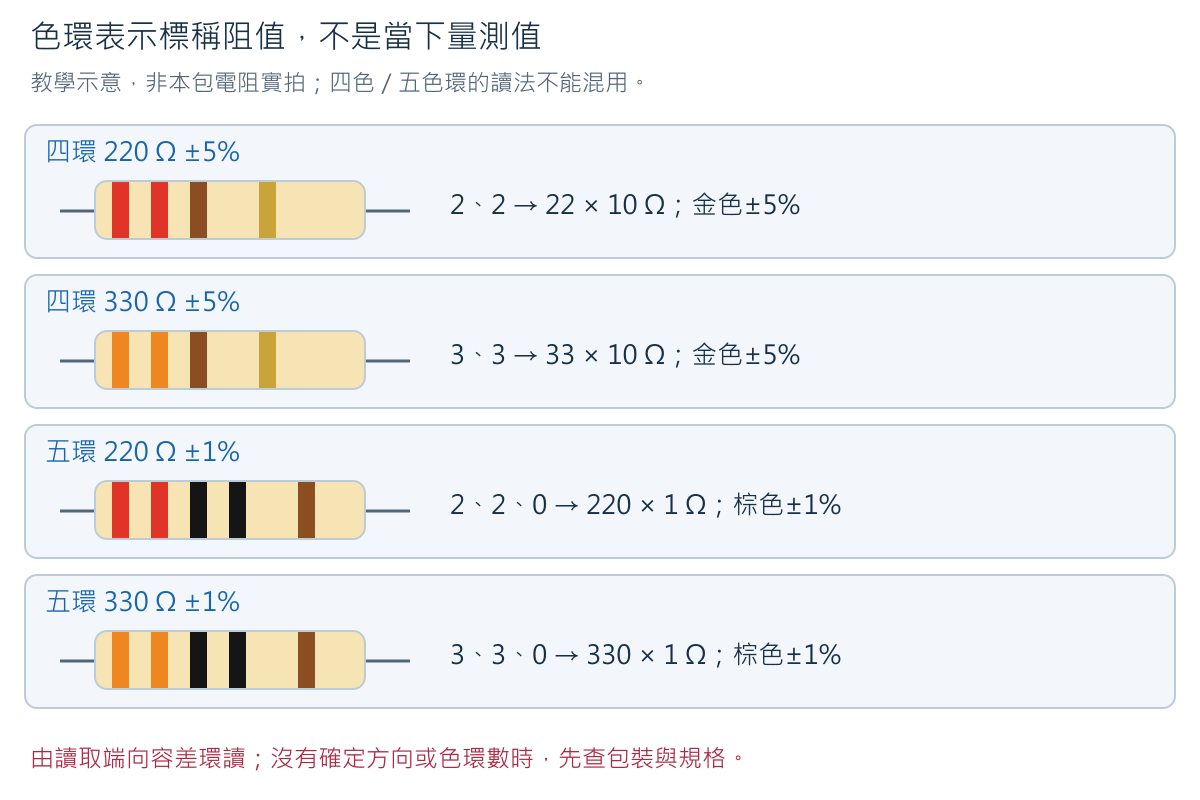

四環用前兩環組成數字、第三環作倍率、第四環作容差。
例如紅－紅－棕－金：紅=2、紅=2，組成22；棕在倍率位置是×10；
22×10＝220 Ω；金在末環表示±5%。不是把2＋2＋1相加。
橘－橘－棕－金則是33×10＝330 Ω±5%。

五環用前三環組成數字、第四環倍率、第五環容差。
紅－紅－黑－黑－棕：220×1＝220 Ω，最後棕是±1%；
橘－橘－黑－黑－棕：330×1＝330 Ω±1%。同樣是棕，位置不同意思也不同。
容差環常與其他環間隔較大，但不能只靠間距硬猜；顏色不清時保留包裝、
換充足照明確認，再獨立量測。沒有色環或環數不同，查該包標示，不能硬套這四例。

**練習R1：** 某顆是橘－橘－黑－黑－棕，另一顆是紅－紅－棕－金。
分別寫出環數、完整算式、Ω／kΩ值，以及容差從哪一環來。

**預期回答與理由：** 第一顆五環，330×1＝330 Ω＝0.330 kΩ，末棕±1%；
第二顆四環，22×10＝220 Ω＝0.220 kΩ，末金±5%。
錯把五環第三個黑當倍率會丟掉第三個有效數字。
這些答案只適用題目給定色環，不代表已辨認你桌上的兩顆；不一致時先保留標示查核。

### 3.3 有電表還需要電阻嗎？

需要。電表是觀察工具，散裝電阻是被量的元件，兩者角色不同。
本題以已知標稱值練習量程，後續才用不同工具判讀未知感測數字。
220／330 Ω此時只接電表量測，不接3V3作負載，也不拿來替代DHT11的上拉設計。
Week 3的1 kΩ／10 kΩ分壓已處理電壓與電流，本週不再搭一遍。


<a id="w4-range"></a>

## 四、量程比較：數字消失，不一定是元件壞了

### 4.1 先指認自己的電表

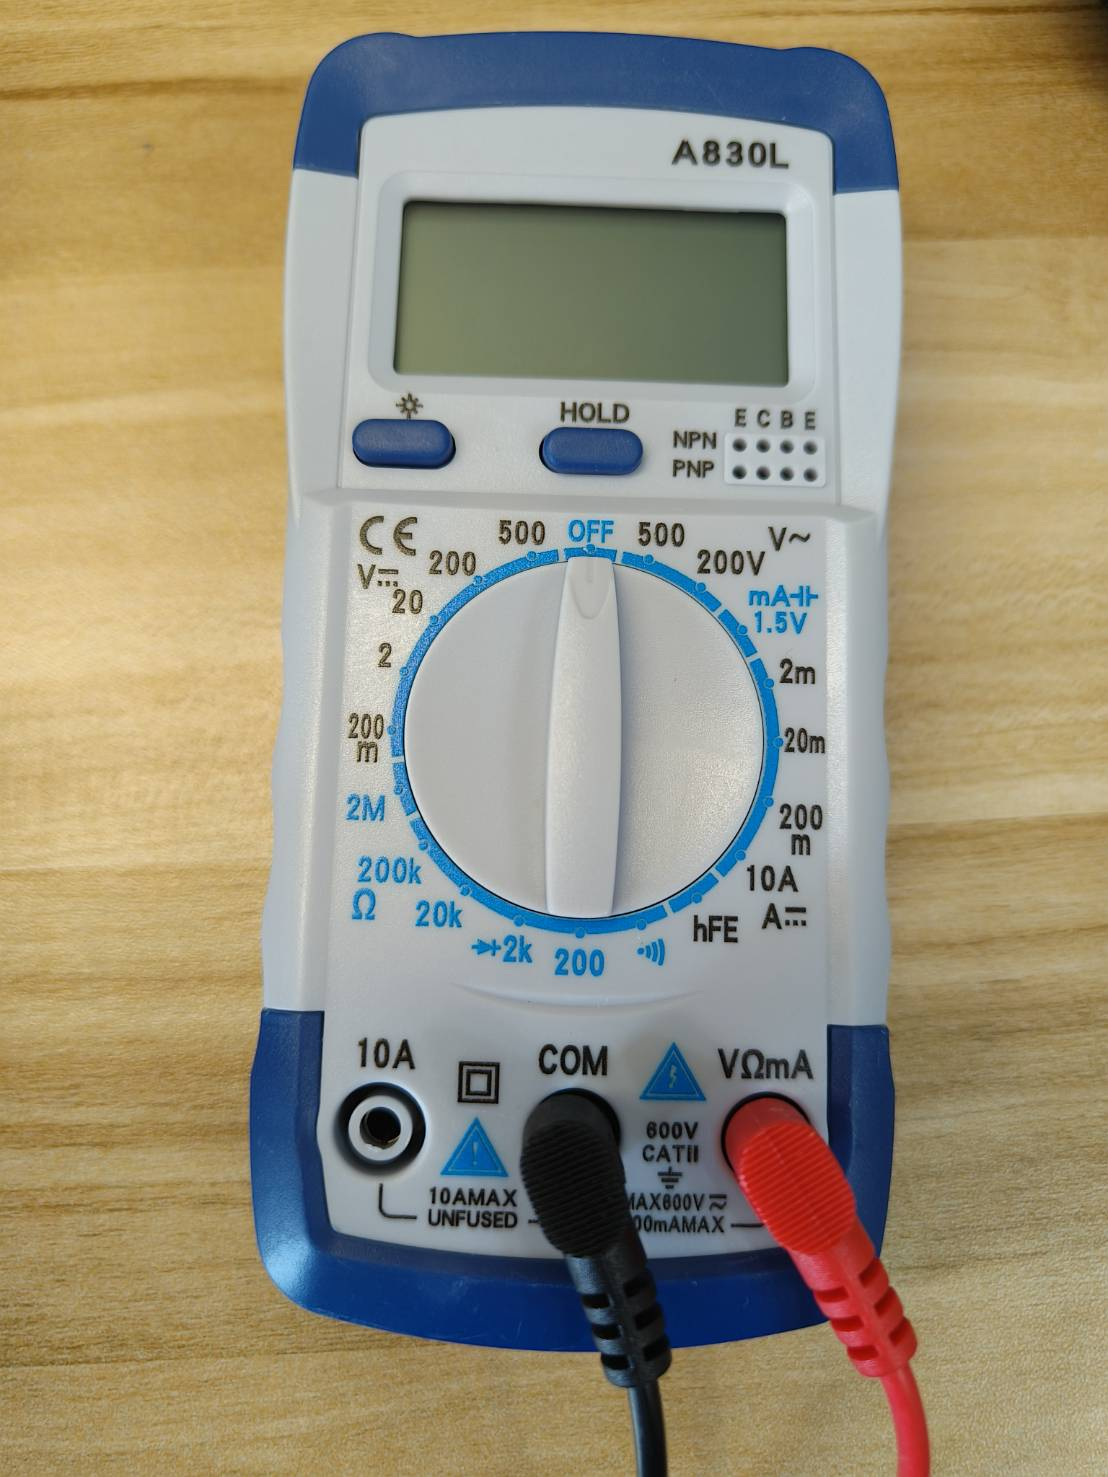

這是已有的A830L實拍，不是現在替你確認旋鈕位置。黑色COM插孔是電表參考端，
與開發板背面的COM USB接頭不是同一種功能；紅表筆用VΩmA或自己型號的VΩ孔，
10A保持空。照片藍色Ω區包含200、2k、20k等範圍；黑／藍印刷不是正／負電。
量程是這次功能能顯示的範圍，不是電表要把200 Ω或20 V「送到」元件。

一般手動表的200 Ω檔上限略低於200 Ω；220與330均大於此範圍，
所以應換可涵蓋它們的Ω量程。A830L照片的2k位置與二極體符號相鄰，
須依手上機型核對Ω功能與單位，不能把二極體壓降mV當成Ω。
本課尚未取得這一批A830L完整原廠手冊；已有教師220 Ω的口頭讀值回報，沒有完整LCD照片或330 Ω實測，
不把下圖當作已核驗的機型標準輸出。不同電表以自己的手冊、功能選擇與顯示單位為準。

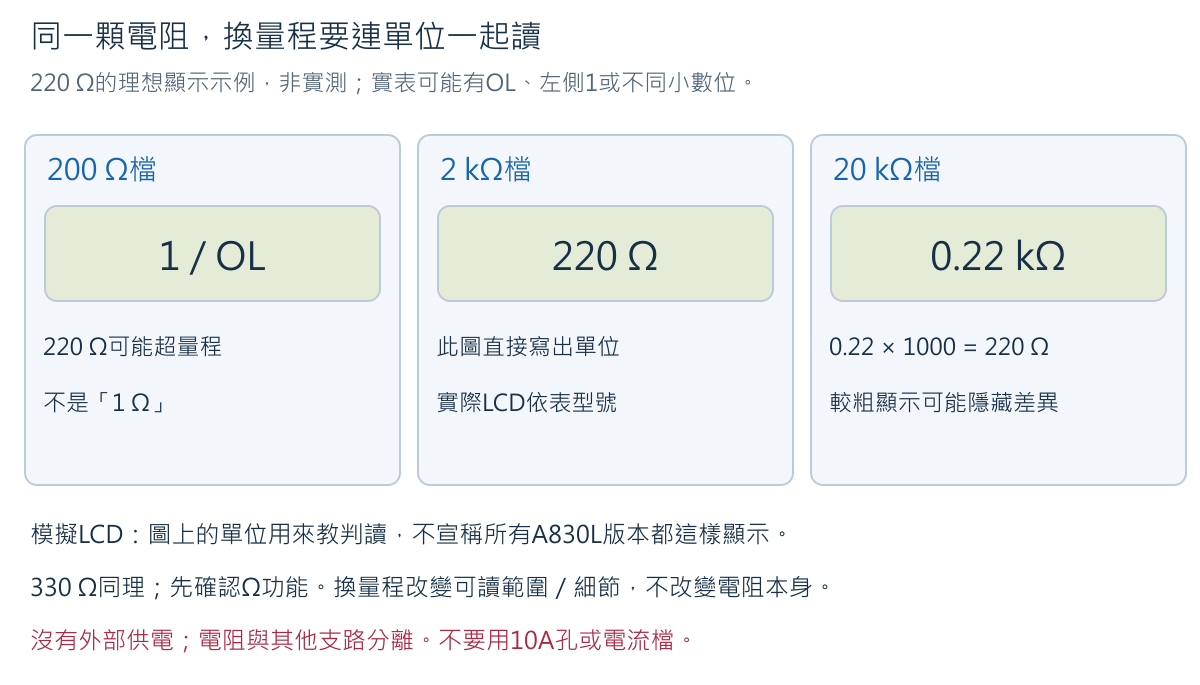

圖中是**典型手動表的示例**：在以Ω顯示的2k檔，220表示約220 Ω；
在以kΩ顯示的20k檔，0.22表示0.22 kΩ＝220 Ω。
若你的表會自動顯示kΩ，0.220 kΩ也是220 Ω。先看功能、量程、小數點、單位，
不能只抄一個「220」或「0.22」。

過小量程可能顯示最左側單獨`1`或`OL`，這是超量程／開路提示，不能填1 Ω。
同樣提示也可能來自探棒根本沒接觸，故需用合適量程與接觸檢查區分。
更大量程可能丟掉細節：假設220與224 Ω都被量程解析度捨入為0.22 kΩ，
不能據此說兩顆完全相同，也不能說換檔使元件變成另一個阻值。

### 4.1A 為什麼三個檔都顯示1，碰在一起又變0？

先問「兩支表筆正在碰什麼」，再問量程。**表筆分開**沒有經過被測電阻的路徑，
手動表可能在200、2k、20k都顯示最左側1；這時換更大量程不會讓空氣變成220 Ω。
**金屬尖端穩定相碰**是很低阻的路徑，常接近0；0.00 kΩ是此量程顯示不出更細差別，
不是證明導線電阻在物理上絕對為零。**分別碰在隔離電阻的兩端**，才是在量那顆電阻。

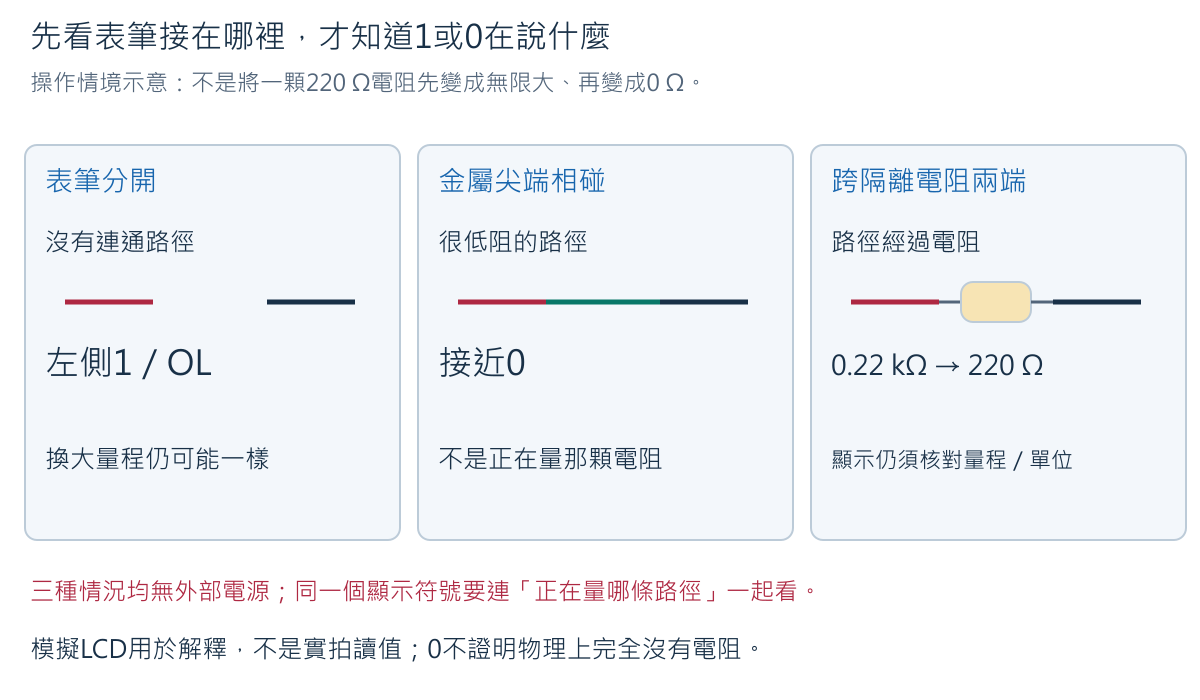

圖上三種情況都沒有外部供電。先用左側判斷開路提示，再用中間確認表筆低阻路徑；
不能拿中間的0說電阻是0，因為電阻根本沒進入量測路徑。
教師本次回報：表筆分開，200／2k／20k皆為1；尖端相碰最後皆接近0；
固定標為220的電阻後，20k為0.22，改200為1。這些是**使用者回報**，非補拍的LCD或校準證明。
在Ω功能及kΩ顯示前提下，0.22×1000＝220 Ω；配合小量程提示，支持量程不足的判讀。
330 Ω尚無本次實測。已完成的220例子不要求教師為了格式重做。

**200與2M差在哪？** 同屬Ω功能時，200表示約200 Ω量級的範圍；
2M表示2 MΩ＝2,000,000 Ω量級。M是百萬、k是千，不是正負極或電池強度。
像拿長尺量很短的物件，量得下不等於讀得細；類比回到電表，就是量程與解析度不同。
實際可顯示上限、小數位及誤差仍依型號。不要把Ω（歐姆，ohm）誤讀成π。

### 4.2 先固定元件與測點，再拿表筆

1. USB拔除、電表OFF，麵包板為空，ESP32與所有模組未接測試區。
2. 取220 Ω一顆，將兩腳輕彎，分別插入**b20與b25**。不要把兩腳放在同列a～e。
3. 兩條公對公線分別插**e20、e25**；自由端分開放在不導電桌面，可固定絕緣部分。
   表筆稍後碰外露公針，不把粗表筆塞進麵包板，也不用手指捏住兩個金屬端。

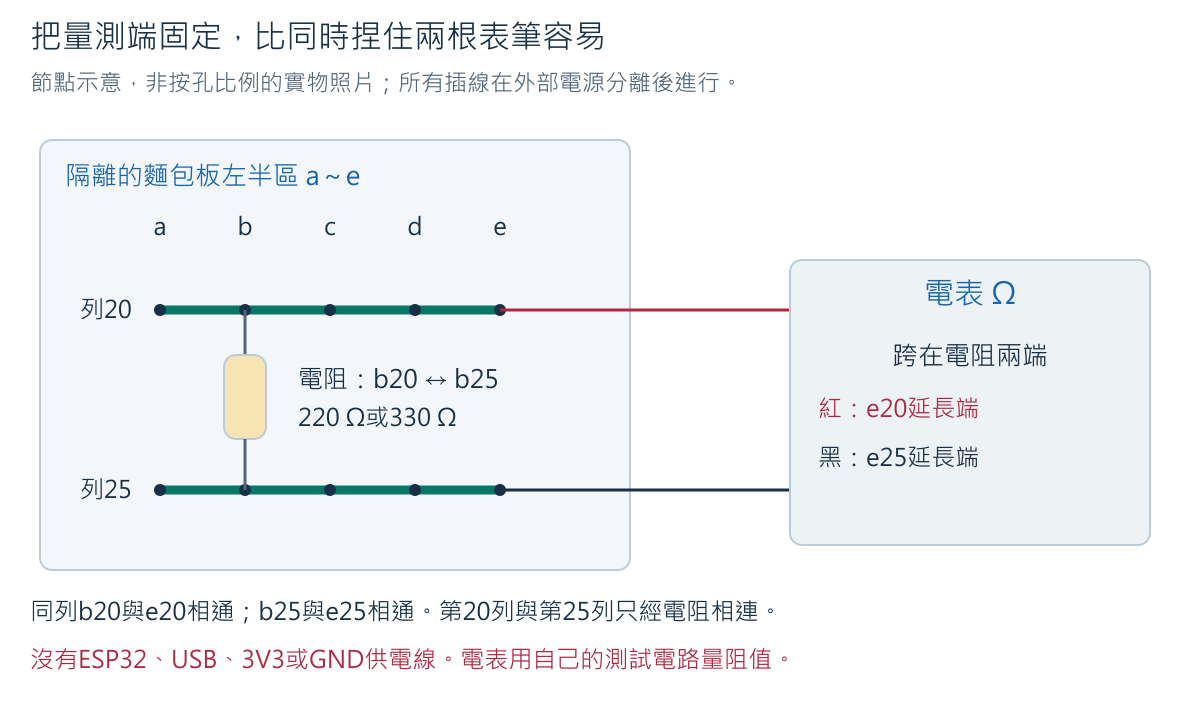

圖左：b20與e20同節點，b25與e25同節點，中間只有被測電阻。
電表透過自己的測試電路量兩端阻值，不需ESP32的GND或USB供電。
圖右是電表跨接兩個測點。另想一個**不要照做的錯例**：若電阻兩腳都插第20列，同列金屬片會繞過電阻，
讀到低阻路徑不能代表電阻本體是0 Ω。這裡用的是Ω檔，不套用電壓檔的紅減黑公式。

### 4.3 依電表類型完成同一個學習任務

**先預測R2：** 同一顆220 Ω，換成200 Ω範圍會怎樣？換到較大量程會不會把它變大？
先寫原因，再量。

**手動量程：**

1. 黑插COM、紅插VΩ或VΩmA。先選已確認的Ω功能及能涵蓋330 Ω的量程；
   典型手動表可用2kΩ，若2k位置的功能尚不確定，先用已確認的20kΩ，
   並記錄較粗的顯示；不要靠猜測二極體功能完成阻值換算。
2. 紅表筆碰e20自由端、黑表筆碰e25自由端，與圖中相同。固定電阻沒有正負極，本步驟選此順序只是方便重查。
3. 穩定後記錄「元件標稱值／檔位／完整畫面／換算Ω／接觸情況」。若不穩，
   移開表筆、維持外部斷電，先檢查端點與固定，不急著判電阻故障。
4. 移開兩支表筆，改到已確認的200 Ω範圍，再碰同一對測點。記錄完整提示與位置，
   不為消除提示而插電、改10A孔或把兩端短接。
5. 移開表筆，回到原來的可用Ω量程，確認能再取得讀值；只需一筆確認，不重收一套資料。
   若仍超量程，檢查包裝、是否量到正確元件及接觸，不能由單獨`1`確診斷路。
6. 移開表筆、電表OFF，取下220 Ω，放好標籤。換330 Ω到同一對孔，重複上述比較。
7. 若電表具有另一個更大Ω量程，可用同一顆330 Ω比較顯示位數；記錄是否少了細節。
   這是同一量程任務的比較，不額外增加重複測量配額。

**自動量程：** 選Ω後親自量兩顆、保存Ω／kΩ單位與小數點，按手冊確認能否用RANGE鍵
切換手動範圍。不能手選範圍者，不必另買電表；以本節**已標示的模擬圖**回答過小／較大
量程會怎樣，並將紀錄註明「畫面判讀，非本人切檔實測」。實際220／330量測仍須完成。

**R2預期回答：** 標稱220 Ω超出約200 Ω範圍，預期超量程；同一顆換量程不等於阻值改變。
需同一元件、同一測點作比較；合適量程有讀值、小量程出提示，才支持「量程不足」的解釋。
若兩檔都出提示，可能接觸不良、物件認錯或其他原因，不能只答「因為220比200大」。

### 4.4 標稱值與測值不同，怎麼解釋

**練習R3（示例，非實測）：** 標稱330 Ω、末環金色，合適量程讀到326 Ω。
先算相差多少Ω與百分比，再說能不能宣稱「精度合格」。

**解答：** 326−330＝−4 Ω；差異幅度4÷330×100%≈1.21%。
金色容差±5%對應330×0.05＝16.5 Ω，即313.5～346.5 Ω；
326在這個**標稱容差帶**內，與330 Ω元件相符，但沒有儀表精度及接觸評估，
不能說完成精密認證。常見錯誤是把−4 Ω當負電阻，或把1.21%當成此電表的精度。

完成後兩顆分開標示收回材料包，移開表筆、電表OFF，拆下測試線與電阻。
下一節重新建立感測器線路，不讓第20／25列舊接法留在供電路徑中。


<a id="w4-sampling"></a>

## 五、承接Week 3：同一個數字，現在要決定能不能觸發聲音

本週不重做KY-018電阻、分壓、ADC或兩套校正取樣。
先取出上週自己的室內光／遮光兩組基準、四個min/max、門檻與獨立驗證。
若換了模組、供電、ADC設定、位置或遮光方式，只重查受影響的基準，不能盲目沿用。
完整計算及重疊反例在[Week 3第十二之一節](../Week_03_Electrical_Measurement_and_ADC/week3_main.ipynb#w3-classification)。

### 5.1 用既有數據區分波動與動作

**教學示例：** 室內光300、304、308、312、316、320、304、308、312、316。
最小300、最大320，全距320−300＝20；總和3100÷10＝平均310。
平均只是一個摘要，不能顯示每一筆的順序與波動。
另一組若也平均310，卻有200與420，全距至少220，不應說兩組一樣穩定。
這是閱讀練習，不要求重收自己的20筆。

**問題：** 門檻610，raw在609、612、608、615間變動，可以每次大於610就響一次嗎？

**預期解答：** 可以寫出這樣的程式，但它會把邊界波動當多次事件。
要辨認一次動作，還需知道「之前是否已穩定解除」「這次遮光是否維持」「遮住後是否尚未解除」。
不能從四筆跨界直接斷言有人遮了兩次。這不是按鈕機械接點彈跳的證據；
本例借用持續確認的思路處理光線分類波動，光敏元件不是機械按鈕。

### 5.2 取樣與顯示不是同一個頻率

整合程式每50 ms檢查KY-018，每500 ms輸出一次摘要。50 ms＝0.05秒；
約一秒20次檢查，約一秒2行摘要。不是每一筆內部樣本都印在螢幕上。
摘要的`sample`可能一次增加10左右，這不等於遺失了應列印的10行。
遮光事件（cover event）另行印出，完整log應同時保存事件及摘要。
若要研究更快的波形，這份摘要不足；本週不因此宣稱任何短動作都能被捕捉。

## 六、穩定狀態與新事件：遮著不放，只算一次

### 6.1 三個不同的名稱

| 名稱 | 它是什麼 | 具體例子 |
|---|---|---|
| 候選狀態（candidate） | 最近一次raw跨門檻後的暫定分類 | 此筆900在遮光側，candidate＝1 |
| 穩定狀態（stable state） | 候選持續至少150 ms後才接受的分類 | 遮光候選持續，stable＝SHADE |
| 新遮光事件（cover event） | 先穩定解除，再穩定遮光的一次轉換 | 事件計數加1，要求一次短鳴 |

150 ms是本課教學參數，不是KY-018原廠規格。原始值不必每筆完全相同，
只須候選分類在此段時間相同；例如900、910、905都在遮光側，可以持續同一候選。
如果中途跑回另一側，候選計時重新開始。圖中箭頭表示時間，不是供電路徑。

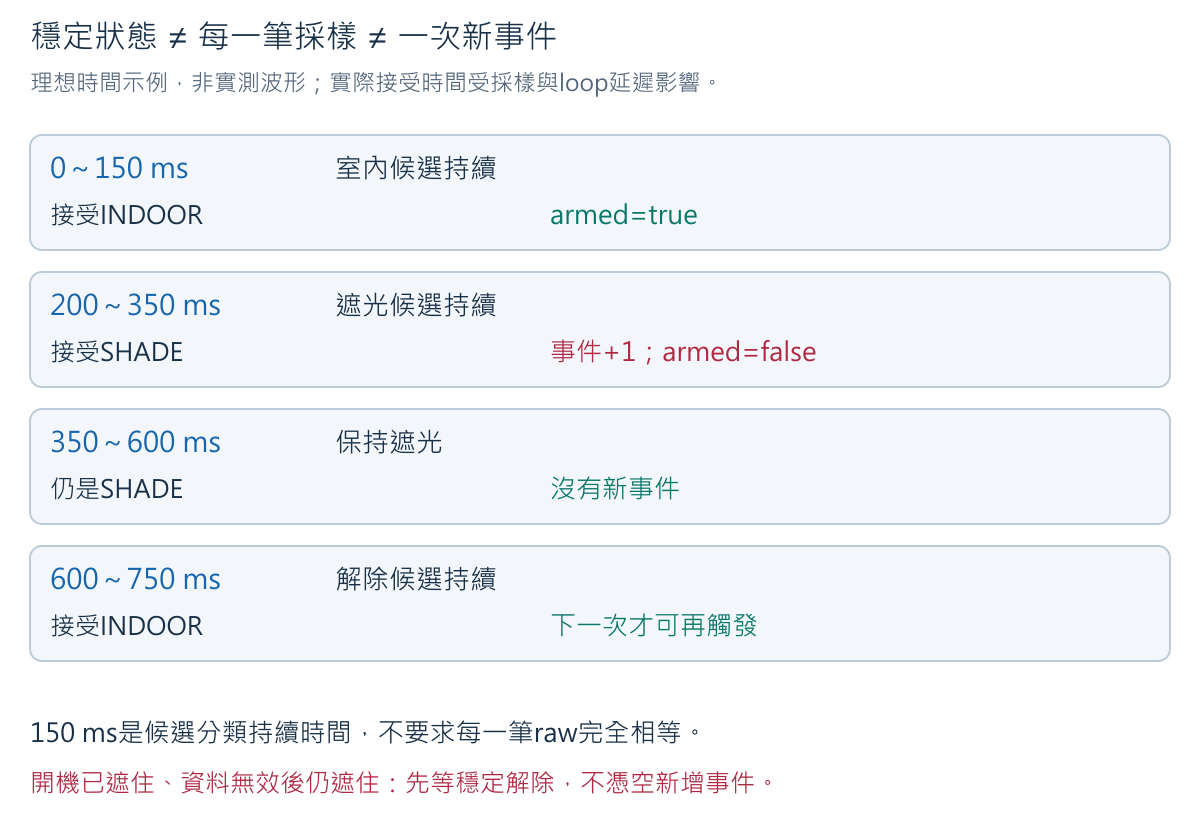

逐段讀圖：0～150 ms都判室內光，150 ms接受解除並設定`armed=true`；
200 ms開始遮光候選，到350 ms才接受遮光、發出事件並取消armed。
之後維持遮光並不新增事件；600 ms解除候選，750 ms才重新準備，下一次遮光才可能再計一次。
**這些時間是理想教學輸入，真實以採樣及log為準。**

### 6.2 為什麼開機時遮住，不先送一聲？

程式不知道這是新動作，還是電源接上前就已經遮住。
因此開機及無效資料後都從`UNKNOWN`開始，必須先有穩定室內光才準備接收一次遮光。
這個規則避免重設或缺值恢復被誤算成新動作，不是感測器天生能辨識玩家意圖。

**練習L1：** 先遮住再接電、持續遮住2秒、移開300 ms、再遮住300 ms，預測事件數。

**參考答案：** 前2秒不算；移開並穩定後準備好；最後穩定遮光才有1個事件。
成立條件是原始值落在有效範圍、分類方向正確、動作確實持續且程式有採到。
若實測不是1，先保存log看candidate／state／armed，不直接把STABLE_MS改0掩蓋原因。

## 七、本週共同成果的接續順序

先完成DHT11單獨實作，知道新模組每一根線及每一欄數字的意義；
再到第12A節合併兩種感測器，最後加入已核准的蜂鳴器（buzzer）控制。
不直接從一大張混合接線圖開始。

1. 現在電阻測試已拆除，板子與模組未供電。
2. 第8～10節只接DHT11，先確認真實讀取、單位、失敗與恢復；母對母線有實際DATA用途。
3. 第12A節先保存舊程式與log並斷電；再依新的同時使用接線表加入KY-018。
4. 蜂鳴器供電、控制方式、安靜時準位、電流及上電／Reset安全尚未核准時，停在文件與Verify。
   不用購物名稱KY-012猜測實物HW-508的腳序，不用GPIO直接供應未知負載。

新成果是「兩種來源分開採樣與判讀，穩定遮光產生有界限的聲音提示」。
DHT11失敗不能被KY的正常數字掩蓋；KY事件也不必假裝DHT11每50 ms更新一次。


<a id="w4-dht"></a>

## 八、DHT11：先認識實物，再決定能否接電

### 8.1 藍色格柵、PCB與三根排針

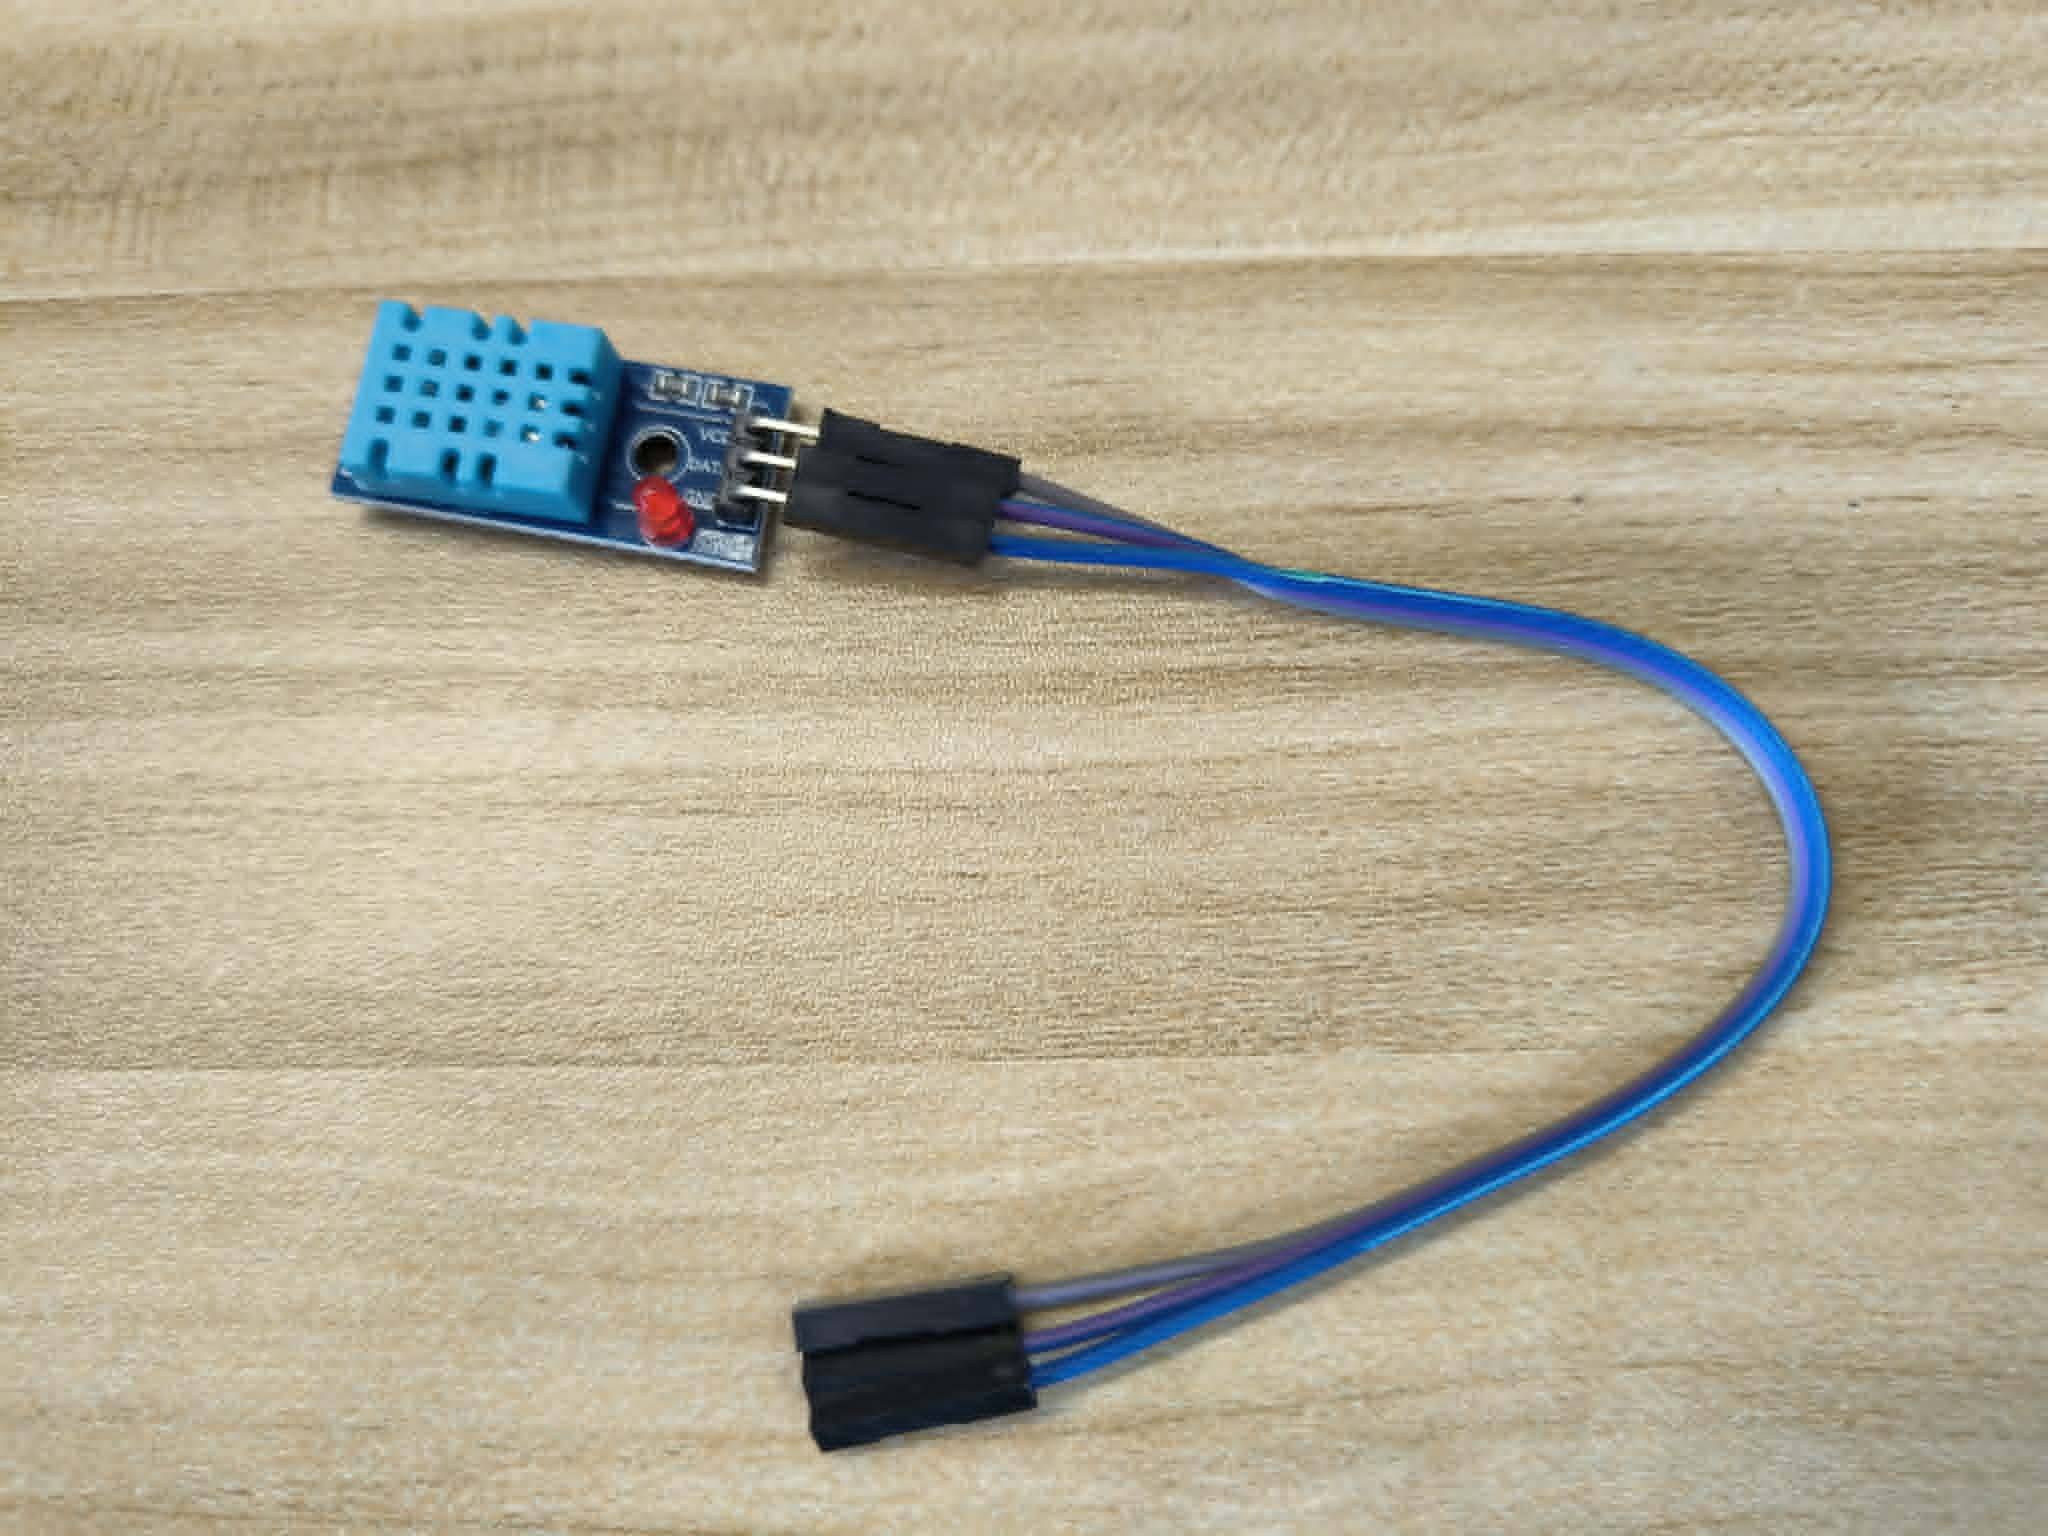

這是本課已取得的**實體照片**，不是接線示意圖。藍色有孔外殼是感測元件；
下面的PCB（印刷電路板）連接元件、排針及板上其他零件。三根金屬排針是與外部連線的接點。
「DHT11」是感測器名稱，「YS-31」是採購清單的模組名稱；相似外觀不保證PCB、腳序完全相同。
LED的存在也不保證它能顯示資料是否正確。

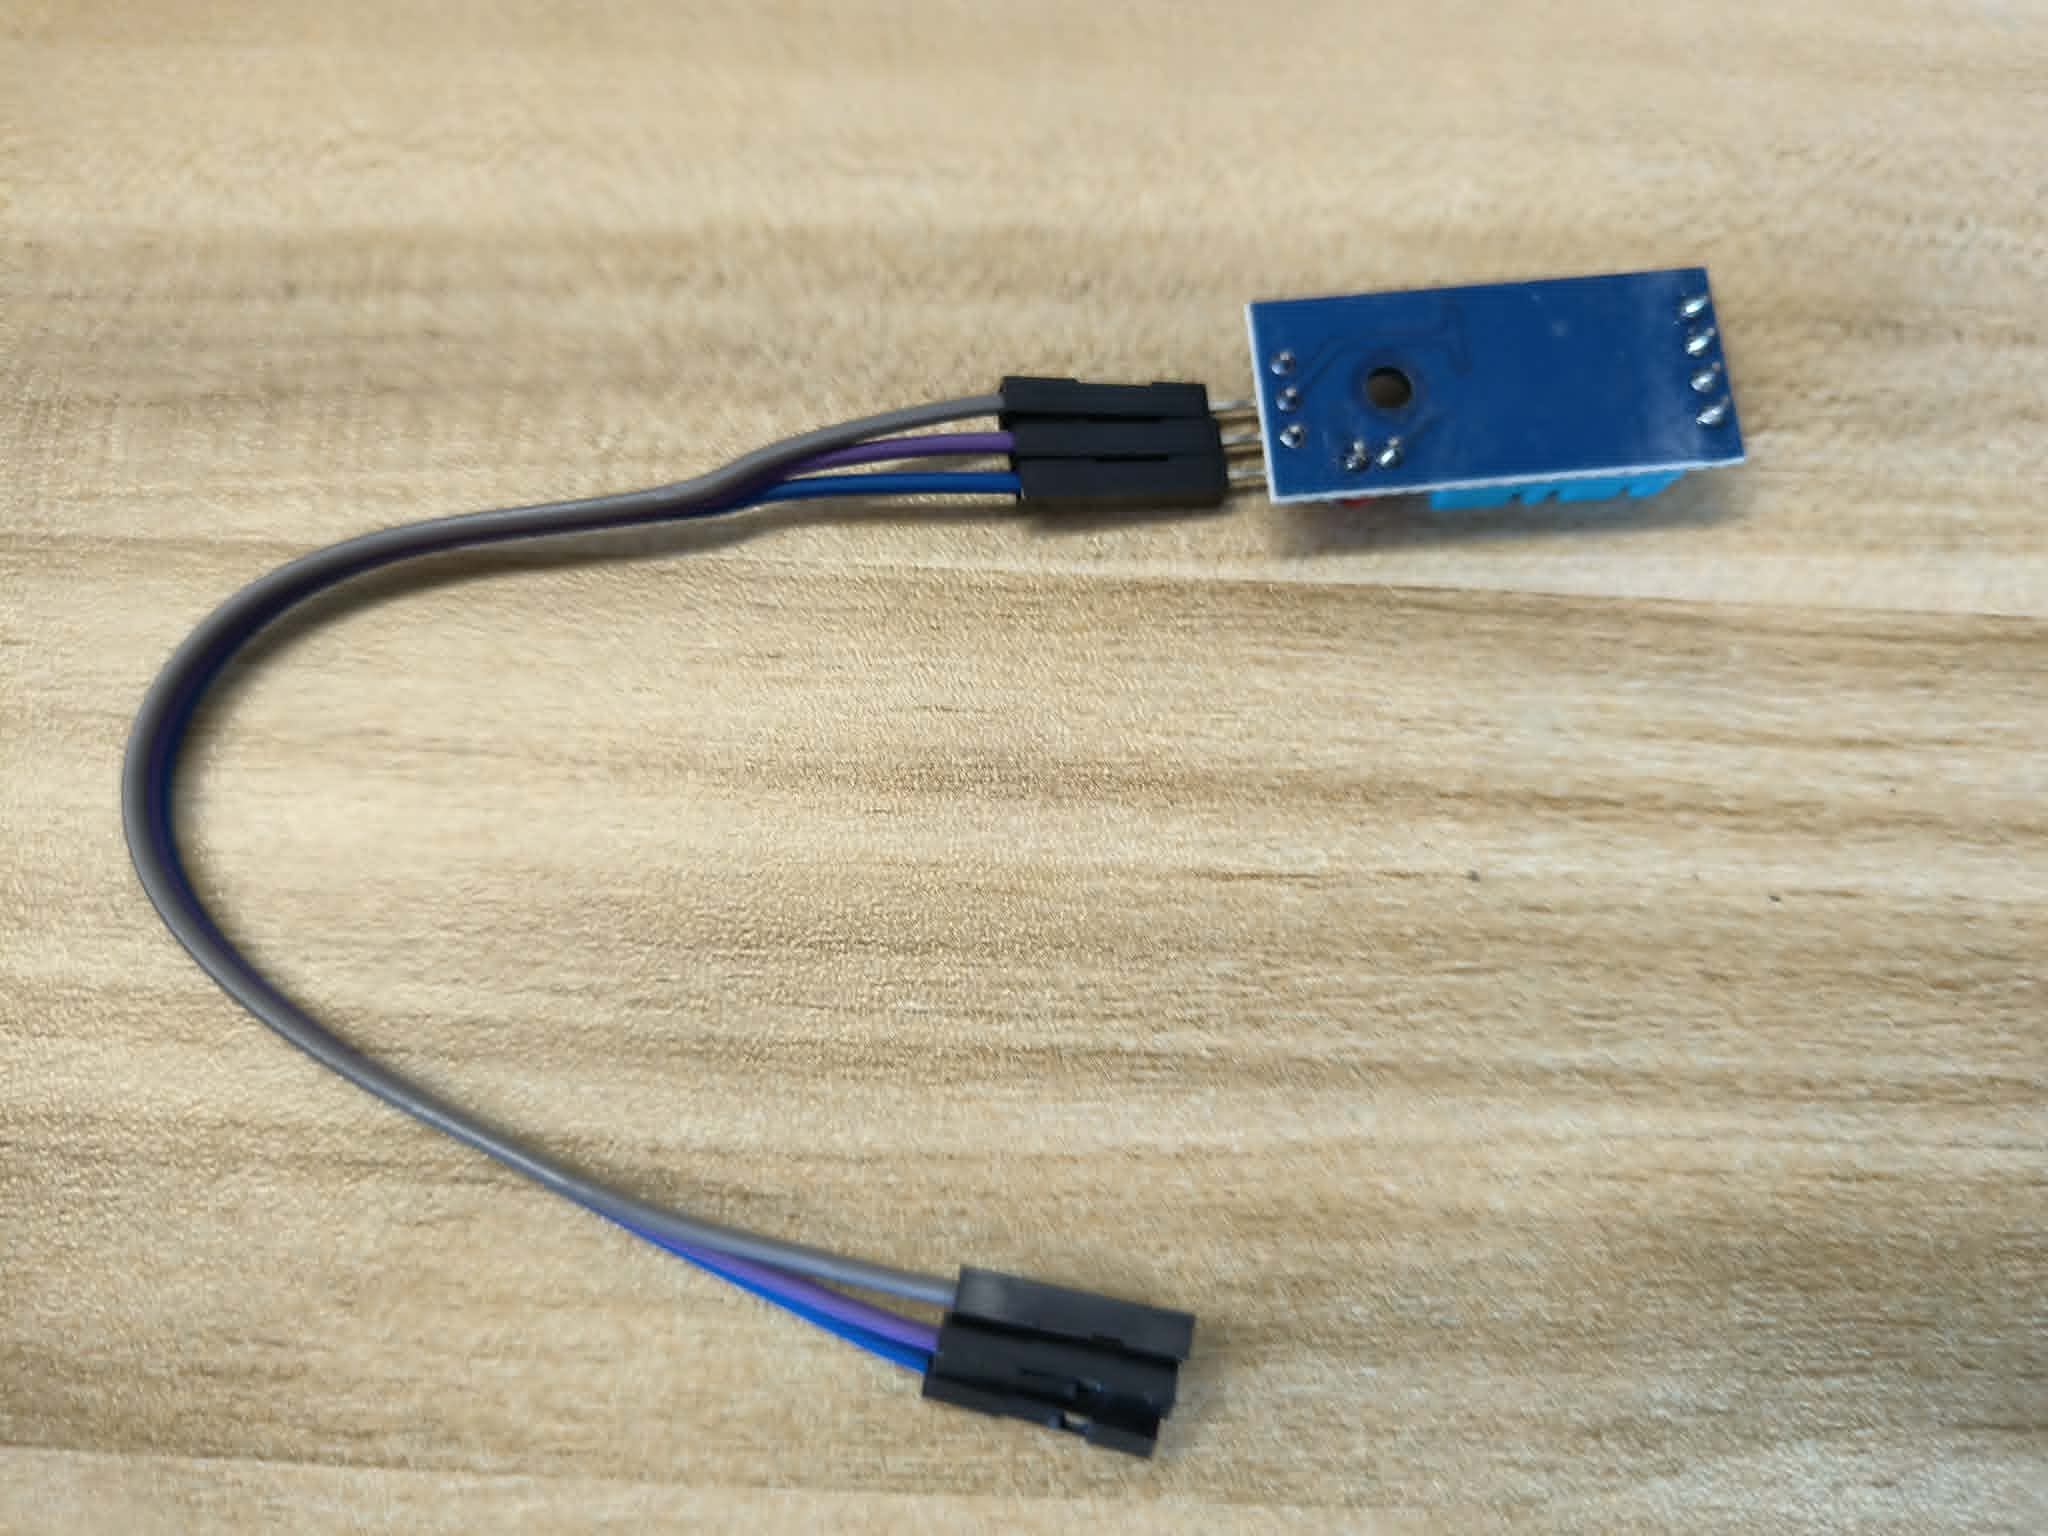

照片上的接頭遮住部分標示。**不要依本照片推定左、中、右就是VCC、DATA、GND**，
也不要把既有灰／紫／藍線當成已確認的功能。先在斷電狀態取下接頭、查看兩面絲印，
再與確切PCB版本的文件及核准紀錄對照；不清楚就停在這一步。

### 8.2 三種功能不是三個可以任意交換的位置

| 功能名稱 | 是什麼、此處的作用 | 不能替代什麼 |
|---|---|---|
| VCC／供電 | 提供模組工作所需的電壓與能量；本週只採已確認可用的3.3 V方案 | 不是資料輸出；不能因沒資料就改接5Vin |
| GND／接地 | 與ESP32共用電位參考，並提供供電回路 | DATA不是GND的替代線 |
| DATA／訊號 | 控制器與感測器用時序交換數位資料的線 | 不是KY-018的連續類比S電壓，不用analogRead換算溫度 |

功能表是理解用的，不是實物腳序。若手上的模組供電或DATA電壓不適用3.3 V系統，
本冊三線方案不能直接套用；交由教師確認，不自行添加器材或改採5 V。

**上拉提醒：** 數位通訊線需要符合感測器規格的閒置準位。上拉電阻是透過電阻把線
接往指定電源，使沒有元件拉低它時有明確的高準位。它不是把電源直接短接DATA。
模組可能已附上拉，也可能不同；須核對上拉接到哪個電源、阻值及邏輯電壓。
程式library不會自動把5 V訊號變成ESP32可接受的電壓。不要因買了220 Ω／330 Ω就拿它們
任意代替通訊上拉；本週這兩顆的任務是獨立辨識與量測。

### 8.3 上電前必須有的核准表

| 核對項目 | 自己這片的紀錄 | 未確認時的動作 |
|---|---|---|
| PCB／感測器標示、正背照片與方向 | 填實際版本與照片檔名 | 不拿其他商店相似照片補空格 |
| 供電、DATA、GND對應實體腳 | 圈出照片上接點並引用確切文件 | 不用顏色或三腳位置猜 |
| 3.3 V供電是否在允許範圍 | 填來源、條件與核准紀錄 | 不接電、不試5 V |
| DATA上拉與輸入／輸出準位 | 填上拉位置、電源、阻值及相容性依據 | 未知視為未核准 |
| ESP32使用GPIO | 填已公布的數位GPIO及profile版本 | 程式保留-1；不沿用ADC候選GPIO當全班答案 |
| 驗證層級 | 文件／編譯／指定實物測試分開填 | 只有照片不能寫「接線已驗證」 |

原廠[ASAIR DHT11入口](https://www.aosong.com/en/Products/info.aspx?itemid=2257)
與[Adafruit DHT接線說明](https://learn.adafruit.com/dht/connecting-to-a-dhtxx-sensor)
可協助理解感測元件，但後者的四腳裸元件圖**不是這片三腳YS-31的接線答案**。
原廠元件文件也不能代替載板電路確認。目前缺少上述實物profile的部分仍是待驗，
不是已完成的感測實驗。

**練習D1：** 同學說「藍色外殼都一樣，把網路圖從左往右照接即可」。問題在哪裡？

**預期回答與理由：** 同名感測元件可裝在不同PCB，排針方向、腳序、上拉與供電設計可能不同。
先關電，辨認確切實物與文件，再逐個功能對照。能編譯只能證明軟體接受寫法；
不能證明電源腳接對。若文件不足，正確結果是待確認，不是猜一個比較像的接法。


## 九、確認後的三線連接：為什麼需要母對母？

### 9.1 這張圖是功能路徑，不是左右腳序

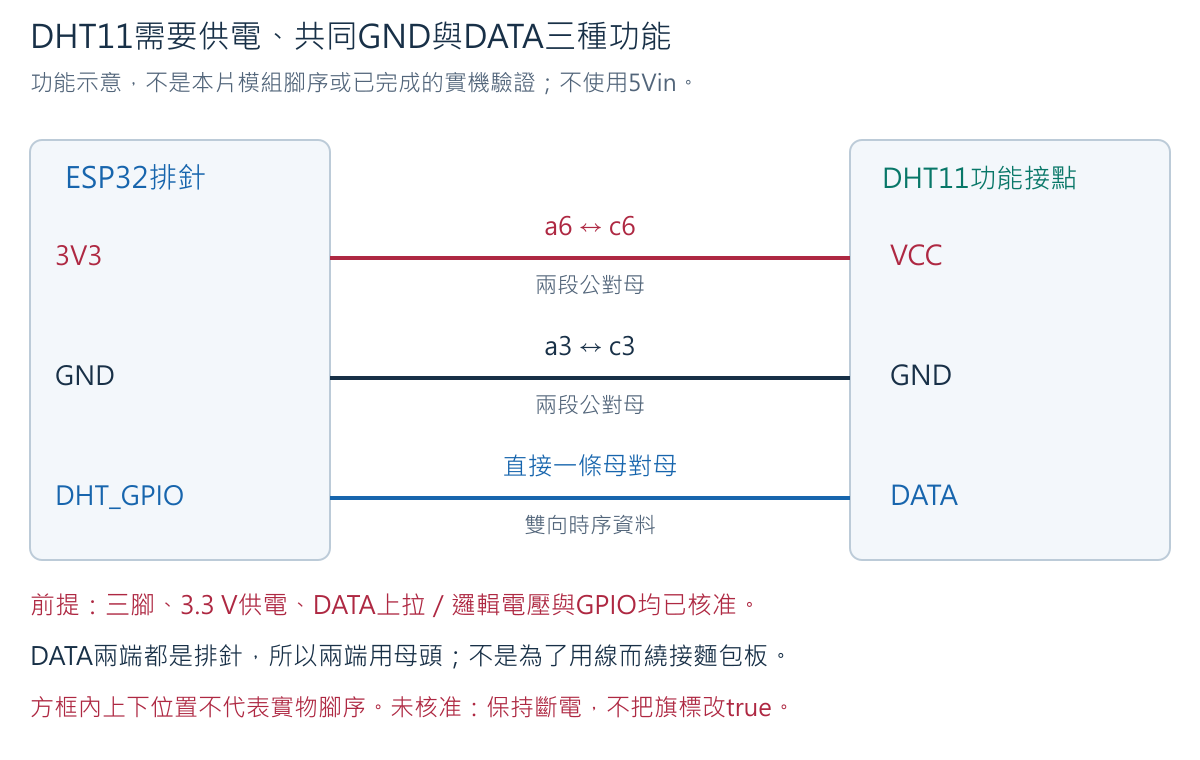

圖上的方框是功能節點，箭頭表示供電方向或資料交換；不是照片上的相對位置。
`DHT_GPIO`指核准表公布的GPIO，不是板上叫這個名字的腳。
ESP32與DHT11兩端都是露出的金屬排針，母對母線的兩端各有金屬插孔，
因此DATA可以直接套接兩個排針，不需要無目的地繞麵包板。
線色方便記錄，不決定功能；記錄「起點→終點」比只寫「藍線」更可靠。

**供電與訊號怎麼串在一起？** 3V3經VCC讓感測器內部電路工作，GND使供電有回路。
DATA傳的是相對共同GND的高低準位與持續時間。控制器先發出請求，感測器再回傳編碼；
library解碼成溫度與濕度。因此DATA不是單獨提供所有能量的一條魔法線，
也不是把GND接上後就等於每個GPIO都變0 V。

### 9.2 先把舊訊號清除，再準備新程式

以下僅適用第8節**全部核准且可用3.3 V**的模組。此階段先單獨測DHT11，
確認後到第12A節才同時加入KY-018與蜂鳴器，不混用兩階段接線表。

1. USB已拔、PWR熄、電表OFF。取下KY-018全部三線，以及連到ADC的線。
   依已保存照片收好，不拆壞模組。a15／c15／e15這次不使用。
2. 保留或重建供電測點：ESP32已辨認的GND以公對母到a3；3V3以公對母到a6。
   a3與a6不同列，不能再用一條線連起來。麵包板紅／藍印線仍不會自行供電。
3. DHT11先不連任何線，依第10節安裝library、設定核准GPIO並Upload新程式。
   此時只有ESP32接USB；未接感測器的讀取失敗可以發生，不能以此宣稱模組故障。
4. Upload完成，關Monitor、拔USB、確認PWR熄滅，再進行下一張接線表。

### 9.3 斷電接線表

| 起點 | 線材與麵包板節點 | 終點 | 理由 |
|---|---|---|---|
| ESP32 3V3排針 | 公對母到a6；另一條公對母的公頭插c6 | 該條母頭套核准的DHT11 VCC | 同列a6～e6供應同一個3.3 V節點 |
| ESP32 GND排針 | 公對母到a3；另一條公對母的公頭插c3 | 該條母頭套核准的DHT11 GND | 同列a3～e3形成共同參考與供電回路 |
| ESP32核准的DHT GPIO排針 | **一條母對母**，兩端確認只套各一根排針 | 核准的DHT11 DATA排針 | 傳遞DHT數位通訊；不經ADC的a15 |

實際接線圖要在自己的照片標註功能，**不要把功能示意圖的上中下當排針順序**。
四條公對母供電線與一條母對母資料線都有明確目的。為了電表較好操作，可於e3、e6
各插一條公對公延長測點，另一端互不碰觸；不把粗表針塞進母頭擴壞插孔。

### 9.4 上電前與第一次結果

1. 對照核准表，從ESP32排針逐線追到模組；不只看線色。確認3V3與GND未直接連通。
   在模組尚未接上的獨立導線／空板節點，可用通斷檢查預期連通與分離。
   模組接上後的電子電路可能影響蜂鳴與讀數；「不響」不能單獨證明整體安全。
2. 電表要測供電時：保持斷電，黑筆COM、紅筆VΩ孔，選直流V且量程高於3.3 V
   （已辨認的A830L用直流20 V）。固定黑筆e3延長端、紅筆e6延長端，兩端勿互碰。
3. 接USB，確認無異常，讀3V3對GND應接近已核對的3.3 V供電；
   若負號，先拔USB再查表筆對調；若明顯偏低、不穩或與profile不符，先拔USB查供電。
   不因數值「大概有電」就繼續讀感測器。
4. 斷電後收起表筆及延長測點，電表OFF；再接USB開115200 baud Monitor觀察。
   不用直流電壓表測DATA上的平均電壓來認定溫度／濕度，數位時序需由library解碼。

**練習D2：** DATA用母對母直連後，能不能拔掉DHT11的GND，因為它已接ESP32？

**答案：** 不能。DATA接到的是通訊GPIO，不是GND。失去GND會破壞正常供電回路及共同參考，
還可能出現不預期的訊號供電路徑；不拿拔地線作實驗。類比成兩人共用一套時間／訊號規則
可以幫助理解，但真正電路要靠供電、GND與DATA三條功能路徑，不是人能猜懂就能省線。


## 十、DHT11如何把環境變成Serial數字？

### 10.1 溫度與相對濕度，不是同一種量

`temperature_c=25.0`表示25.0攝氏度（°C），不是25 V。
`humidity_pct=60.0`表示60.0%相對濕度（%RH），不是空氣體積有60%是水。
相對濕度比較**目前水蒸氣狀態與同溫度下飽和狀態**；溫度改變時，比較基準也會變。
[香港天文台相對濕度說明](https://www.weather.gov.hk/en/education/meteorological-instruments/automatic-weather-stations/00714-Lets-talk-about-relative-humidity.html)

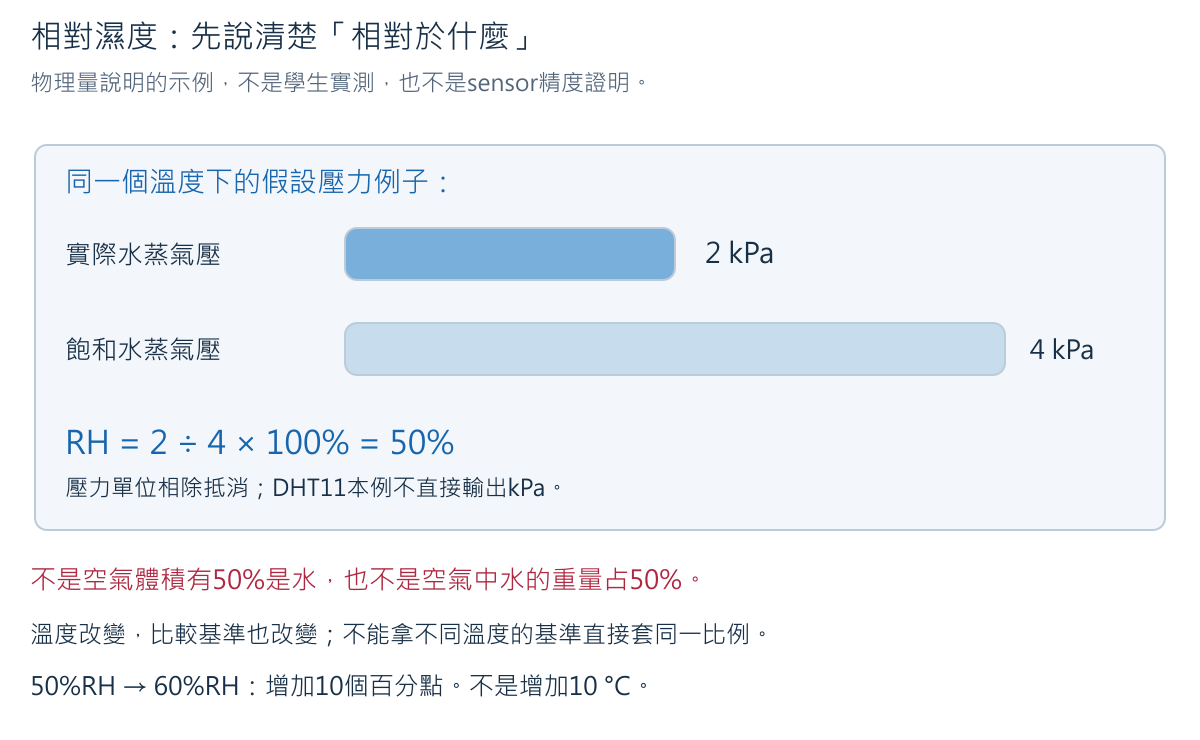

**數字示例，不是DHT11輸出壓力：** 若某溫度下實際水蒸氣壓為2 kPa、飽和水蒸氣壓為4 kPa，
相對濕度=2÷4×100%=50%。兩個壓力單位相除後抵消，結果才是百分比；
不能把2 kPa加上4 kPa算濕度。這裡只用來解釋「相對」，本週不另外量壓力。
Pa（pascal，帕斯卡）是壓力單位，kPa是千帕，1 kPa=1000 Pa；
改成2000 Pa÷4000 Pa，仍得到0.5，也就是50%，不因單位改寫而改變濕度。
溫度變了，不能繼續沿用同一個4 kPa基準。

從50%RH到60%RH增加**10個百分點**，不是增加10 °C；若談相對增幅才是10÷50=20%。
本程式的濕度突變門檻採「百分點差」，避免把兩種百分比說法混用。

### 10.2 KY-018與DHT11的讀取方法不同

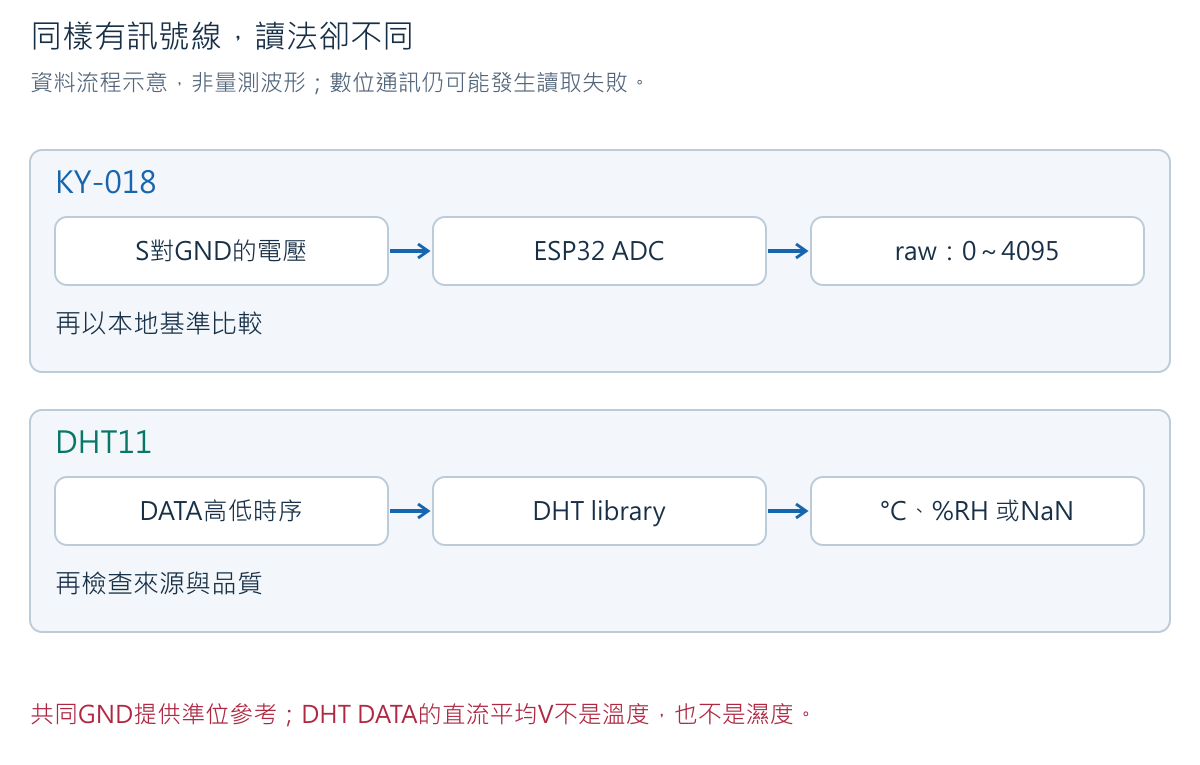

KY-018的S是待量的類比電壓，ADC得到raw；DHT11在DATA線上以高低準位的時間組合傳資料，
library負責請求、等候回覆、解碼與檢查。圖中的高低線只是概念，不是實測波形或可照抄的時序規格。
「數位」不等於一定正確：接觸不良、供電或等待時間問題仍可能使傳輸失敗。

### 10.3 安裝什麼library？為什麼需要它？

Library（函式庫）是可重用程式，讓我們用`readHumidity()`表達「讀濕度」，
不用初學時就自行處理每個微秒脈衝。仍須知道它會回傳什麼，以及失敗時如何判斷。

1. Arduino IDE開`Tools → Manage Libraries…`（或左側Libraries圖示）。
2. 搜尋`DHT sensor library`，確認作者為**Adafruit**，本冊編譯基準版本為**1.4.7**。
   選版本後Install；若已安裝，記錄實際版本，不重複安裝名稱相似的其他library。
3. 安裝相依套件時選`Install All`；確認`Adafruit Unified Sensor`存在，基準版本**1.1.15**。
   本例直接include DHT.h；相依套件仍按套件管理器與library宣告準備。
4. 若課堂選用其他版本，先由教師驗證並更新版本紀錄，不假定所有版本行為相同。

官方來源：[DHT sensor library 1.4.7](https://github.com/adafruit/DHT-sensor-library/tree/1.4.7)、
[該版DHT.cpp](https://github.com/adafruit/DHT-sensor-library/blob/1.4.7/DHT.cpp)、
[Adafruit Unified Sensor](https://github.com/adafruit/Adafruit_Sensor)。
這個DHT library的最短重讀間隔為2000 ms；太快再呼叫可能取得快取結果，
不是每次函式呼叫都完成一筆新的實體量測。本例隔2500 ms啟動一輪，
同輪先讀濕度、再讀溫度，使用同一個資料框，不是兩次獨立取樣。
本課間隔還須符合確切模組規格；library限制不是模組完整性能保證。

### 10.4 完整程式

檔案：[week04_dht11_quality.ino](../examples/week04_dht11_quality/week04_dht11_quality.ino)。
以第8節核准表填`PIN_DHT`，確認表內所有條件後才將`MODULE_PROFILE_CONFIRMED`改為`true`；
`DEVICE_ID`改為非個資的板卡代碼。未核准時保持原值，程式可Verify但不啟用DHT交易。


In [ ]:
#include <DHT.h>
#include <math.h>

// Do not set a GPIO or enable this gate until the exact module is approved.
const int PIN_DHT = -1;
const bool MODULE_PROFILE_CONFIRMED = false;
const char* DEVICE_ID = "CHANGE_ME";
const unsigned long READ_INTERVAL_MS = 2500;
// Classroom warning policy, NOT the DHT11 measurement/operating specification.
const float ROOM_MIN_C = 10.0f;
const float ROOM_MAX_C = 40.0f;
const float JUMP_C = 5.0f;
const float JUMP_RH_POINTS = 10.0f;

DHT dht(PIN_DHT, DHT11);
bool injectFailure = false;
bool havePrevious = false;
float previousC = 0.0f;
float previousRh = 0.0f;
unsigned long previousMs = 0;
unsigned long lastReadMs = 0;
unsigned long sampleNumber = 0;

bool profileReady() {
  return PIN_DHT >= 0 && MODULE_PROFILE_CONFIRMED;
}

void reportReading(float temperatureC, float humidityPct, unsigned long now, bool injected) {
  const char* quality = "usable";
  const char* reason = "basic_checks_passed";
  bool valid = true;
  // Missing is not zero. Never substitute the previous value for this row.
  if (!isfinite(temperatureC) || !isfinite(humidityPct)) {
    valid = false; quality = "invalid";
    reason = injected ? "injected_read_failed" : "read_failed";
  } else if (humidityPct < 0.0f || humidityPct > 100.0f) {
    valid = false; quality = "invalid"; reason = "rh_out_of_bounds";
  } else if (temperatureC < ROOM_MIN_C || temperatureC > ROOM_MAX_C) {
    quality = "suspect"; reason = "outside_classroom_policy";
  } else if (havePrevious && now - previousMs <= 2 * READ_INTERVAL_MS &&
             (fabsf(temperatureC - previousC) > JUMP_C ||
              fabsf(humidityPct - previousRh) > JUMP_RH_POINTS)) {
    quality = "suspect"; reason = "abrupt_change";
  }
  Serial.printf("device=%s sensor=dht11 source=%s sample=%lu uptime_ms=%lu "
                "temperature_c=%.1f humidity_pct=%.1f valid=%s quality=%s reason=%s\n",
                DEVICE_ID, injected ? "injected" : "hardware", sampleNumber, now,
                temperatureC, humidityPct, valid ? "true" : "false", quality, reason);
  // Only adjacent real finite/basic-range records enter the jump comparison.
  havePrevious = valid && !injected;
  if (havePrevious) {
    previousC = temperatureC; previousRh = humidityPct; previousMs = now;
  }
}

void setup() {
  Serial.begin(115200);
  delay(500);
  if (!profileReady()) {
    Serial.println("week=4 sensor=dht11 status=blocked reason=module_or_gpio_profile_missing");
    return;  // No dht.begin(), pinMode(), or sensor transaction before approval.
  }
  dht.begin();
  lastReadMs = millis();  // Give the powered sensor an initial 2.5-second wait.
  Serial.printf("week=4 sensor=dht11 status=ready device=%s pin_dht=%d interval_ms=%lu\n",
                DEVICE_ID, PIN_DHT, READ_INTERVAL_MS);
  Serial.println("commands=f:inject_missing r:resume_hardware");
}

void loop() {
  if (!profileReady()) return;
  if (Serial.available()) {
    char command = Serial.read();
    if (command == 'f' || command == 'r') {
      injectFailure = command == 'f';
      havePrevious = false;
      lastReadMs = millis();  // Mode change also waits before the next sample.
      Serial.printf("event=mode source=%s next_read_after_ms=%lu\n",
                    injectFailure ? "injected" : "hardware", READ_INTERVAL_MS);
    } else if (command != '\r' && command != '\n' && command != ' ') {
      Serial.println("event=command status=rejected reason=unknown_command");
    }
  }
  unsigned long now = millis();
  if (now - lastReadMs < READ_INTERVAL_MS) return;
  lastReadMs = now;
  sampleNumber++;
  float temperatureC = NAN, humidityPct = NAN;
  if (!injectFailure) {
    humidityPct = dht.readHumidity();
    temperatureC = dht.readTemperature();  // Same cached frame, not another 2.5 s cycle.
  }
  reportReading(temperatureC, humidityPct, now, injectFailure);
}


### 10.5 按程式順序看一輪資料

| 主要名稱／函式 | 具體作用 | 例子與限制 |
|---|---|---|
| `DHT dht(PIN_DHT, DHT11)` | 建立使用指定腳位及感測器類型的物件 | 不是接上實物；DHT11不能隨意改成DHT22 |
| `profileReady()` | 要求GPIO已填且人工確認旗標為true | 旗標是操作閘門，不是自動量測電壓的功能 |
| `dht.begin()` | 初始化DHT腳位／library | 只在profile通過後執行 |
| `READ_INTERVAL_MS=2500` | 每輪至少等待2.5秒 | 2500 ms÷1000=2.5 s，不是2500筆／秒 |
| `now-lastReadMs` | 算距上輪多久；未到期立即返回loop | 上電與切模式後也等2.5秒；不靠手動連按取得「新」資料 |
| `readHumidity()`／`readTemperature()` | 取得%RH及°C；後者預設攝氏 | 同輪快取相同資料框；不是量DATA對GND的平均V |
| `NAN`／`isfinite()` | NAN代表非有效數值；isfinite檢查是否有限數字 | NaN不是0 °C，不能直接拿來平均 |
| `reportReading()` | 依順序檢查並把值與品質一起印出 | 第11節說明先後順序；不是看到第一個數字就成功 |
| `havePrevious`／`previousC`等 | 保留前一筆通過基本檢查的真實資料，比較短時間差 | 失敗或切模式清除比較，首次恢復不跨缺口比較 |
| `injectFailure`／`f`／`r` | 切換軟體缺值注入及真實讀取 | f不真的破壞感測器；r也不保證真實讀取必成功 |

`ROOM_MIN_C=10`、`ROOM_MAX_C=40`是本課**一般教室的警示政策**，
不是DHT11原廠量測範圍；`JUMP_C=5`與`JUMP_RH_POINTS=10`也是待用途檢討的課堂規則。
精確規格由第8節模組文件與驗證紀錄確認。數值通過規則不能替代校正或精度驗證。

**逐輪示例：** now=3000、lastReadMs=500，差2500，於是讀一個資料框；
取得25 °C、55%RH後印一列並保存前值。下一圈now=3001，差1，先返回，
不再讀取。這是時間控制，不是程式停擺；loop仍會查看Serial是否收到命令。

### 10.6 Verify、Upload與第一段真實紀錄

1. 依9.2保持DHT11未接、只連ESP32進行Upload。IDE `File → Open`開本節`.ino`，
   核准後填設定、另存自己的同名sketch資料夾。未核准只Verify，不繼續硬體步驟。
2. 按7.4相同板卡／Flash／PSRAM／COM設定核對，點Verify。
   `DHT.h: No such file`先查10.3library，不改接線、不將錯誤畫面當Upload成功。
3. 關Monitor、選實際Port、Upload，保存編譯與寫入結果。這次程式取代上一支KY程式，
   不是讓兩支同時在板上跑。寫入完成後斷電，依9.3接DHT11並通過9.4檢查。
4. 上電開Monitor、115200 baud，開場應為`sensor=dht11 status=ready`。
   若`blocked`，先核對設定與核准表；不得只為消除blocked就填任意GPIO。
5. 模組固定於一般室內位置，避開手指長時間接觸、呼氣、液體與熱源。
   先觀察數輪，再連續保存10筆真實資料；把位置、環境與觀察時間寫下。
   不用吹氣或熱水證明濕度會動，也不必強迫數字每筆不同。

以下是**格式與判讀示例，不是本課實測**：

```text
week=4 sensor=dht11 status=ready device=DEMO pin_dht=<核准GPIO> interval_ms=2500
device=DEMO sensor=dht11 source=hardware sample=1 uptime_ms=3000 temperature_c=25.0 humidity_pct=55.0 valid=true quality=usable reason=basic_checks_passed
```

| 欄位 | 如何讀 | 不能當成什麼 |
|---|---|---|
| device／sensor／source | 板卡代碼／感測器名稱／hardware或injected來源 | hardware不等於實物接線已被程式確認 |
| sample | 本次開機累計嘗試讀取的輪次，失敗也加1 | 不是「第幾次成功」，不能跳過失敗列 |
| uptime_ms | 本輪發起時距開機的毫秒數 | 不是日期，也不是感測器的保證精確取樣時刻 |
| temperature_c | 攝氏溫度；此例25.0 °C | 不是ADC raw或電壓 |
| humidity_pct | 相對濕度；此例55.0%RH | 不是水占空氣體積55% |
| valid | 通過有限值及基本RH範圍檢查 | true不是已校正、已證明準確 |
| quality／reason | 本課判斷及原因 | usable只表示通過本程式已做檢查 |

`%.1f`使顯示有一位小數，不會讓DHT11突然有0.1 °C的測量精度。
程式每約2500 ms嘗試一輪；10筆首尾相隔約22500 ms（9個間隔），
需等10筆而不是計時22.5秒後假設一定收齊。保存實際序號、時間與缺行。

**練習D3：** 連續三筆25.0 °C、55.0%RH，uptime分別3000／5500／8000。
是否證明程式卡住？若顯示25.0，是否代表誤差只有0.1 °C？

**答案與推理：** 序號與時間持續前進，支持程式仍在嘗試讀取。穩定環境、感測器分辨能力
及更新特性都可能使數值相同；同值不足以確診卡住，也不足以保證sensor每輪都更新。
顯示位數是格式，精度須由規格與比較實驗證明。先看完整欄位與來源，
不要為了「讓它變」去加熱或弄濕元件。


<a id="w4-quality"></a>

## 十一、有數字、基本有效、適合判斷：三層問題

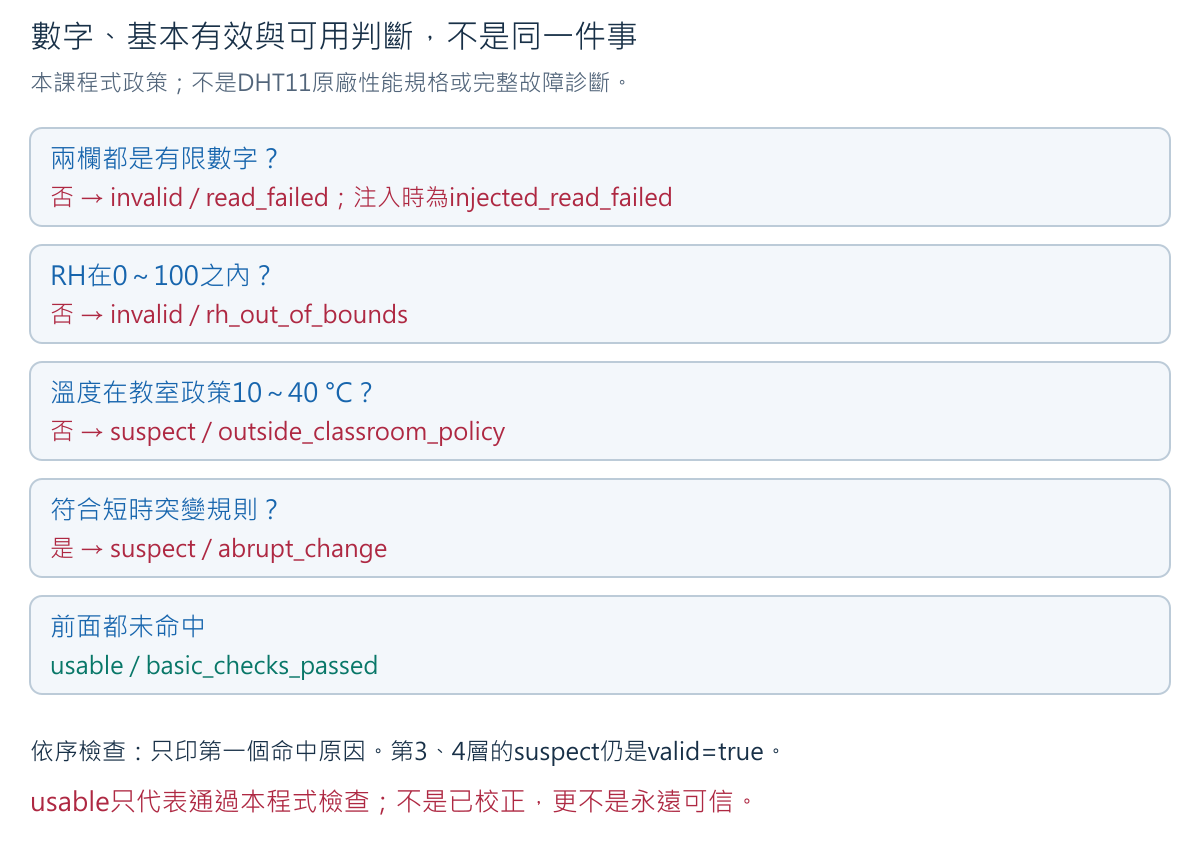

**第一層：這一輪有可運算的數值嗎？** `NaN`代表缺少有效數值；保留整列並標invalid，
不能改成0或上次的25。若把上次25填進這一輪，別人會誤以為這時真的量到25。

**第二層：數值通過已明訂的基本條件嗎？** 本程式要求兩個欄位有限，RH在0～100內。
示例RH=140雖是數字，仍被判`valid=false`、`rh_out_of_bounds`。
這不是完整原廠規格檢查，0～100也不是宣稱DHT11能準確量完整區間。

**第三層：目前用途下還有值得懷疑的理由嗎？** 例如一般教室顯示45 °C，或2.5秒內
25→31 °C。本程式保留數字並標`valid=true quality=suspect`，不武斷判sensor壞了。
房間真的變熱、位置移動、接觸、干擾、或讀值問題都有可能，需額外證據區分。

### 11.1 順序會決定reason

| 依序檢查 | 條件 | 輸出 |
|---|---|---|
| 1 | 溫度或RH不是有限值 | invalid；真實read_failed或injected_read_failed |
| 2 | RH小於0或大於100 | invalid；rh_out_of_bounds |
| 3 | 溫度小於10或大於40 °C | valid但suspect；outside_classroom_policy |
| 4 | 有相鄰真實基本有效前值、時間差不超過5000 ms，且溫差大於5 °C或RH差大於10百分點 | valid但suspect；abrupt_change |
| 5 | 上述皆不成立 | valid、usable；basic_checks_passed |

同一列只印第一個命中原因。例如45 °C也可能與前值相差很多，但先印教室政策警示。
「大於5」不包括剛好5；「小於10」不包括10。本例選的邊界需明說，不能用直覺替程式改判。
前一筆suspect但基本有效的真實數值仍可作下一輪比較；因此31→31可能不再有突變警示。
警示消失不代表已證明原因排除；它只說這次未再命中相同規則。

### 11.2 兩種感測器的valid，不能互相代替

Week 3的KY分類分開印class與quality；本週控制事件另用lightValid做更保守的檢查。
DHT的valid則檢查有限數字與RH基本範圍。名稱相似不表示規則相同，更不表示已校正。
第12A節同時使用兩者時，每個來源保留自己的valid、source及時間，不用一個總valid掩蓋失敗。

**練習Q1，皆為軟體示例：** 前值25 °C、50%RH，2.5秒後分別輸入：
A=(NaN,50)，B=(25,120)，C=(45,50)，D=(31,50)，E=(30,60)。各會如何判？

**答案與逐步理由：** A在有限值檢查失敗；B在RH範圍失敗；C先命中教室政策；
D溫差6>5，為abrupt_change；E溫差5、RH差10，均未「大於」門檻，為usable。
這五題分別以前值25／50開始，不是把A到E當同一串前值。
常見錯誤是把C/D數字刪掉、把A填0、或把E判成保證可信。
不能由此判斷真正教室環境，也不能宣稱實體DHT11已產生這些資料。


## 十二、安全製造「讀不到」的情境，再回到真實讀取

### 12.1 本次採軟體故障注入，不拔帶電線

**Fault injection（故障注入）**是有意安排一個錯誤條件，檢查系統如何處理。
本週用鍵盤`f`令程式略過DHT讀取，將這一輪兩個值設成NaN。
目的在驗證「失敗會被留下、不變0、不假裝成功」，**不是測試斷線偵測能力**。
不拔帶電DATA、不拔GND、不短接供電，也不弄濕或加熱sensor。

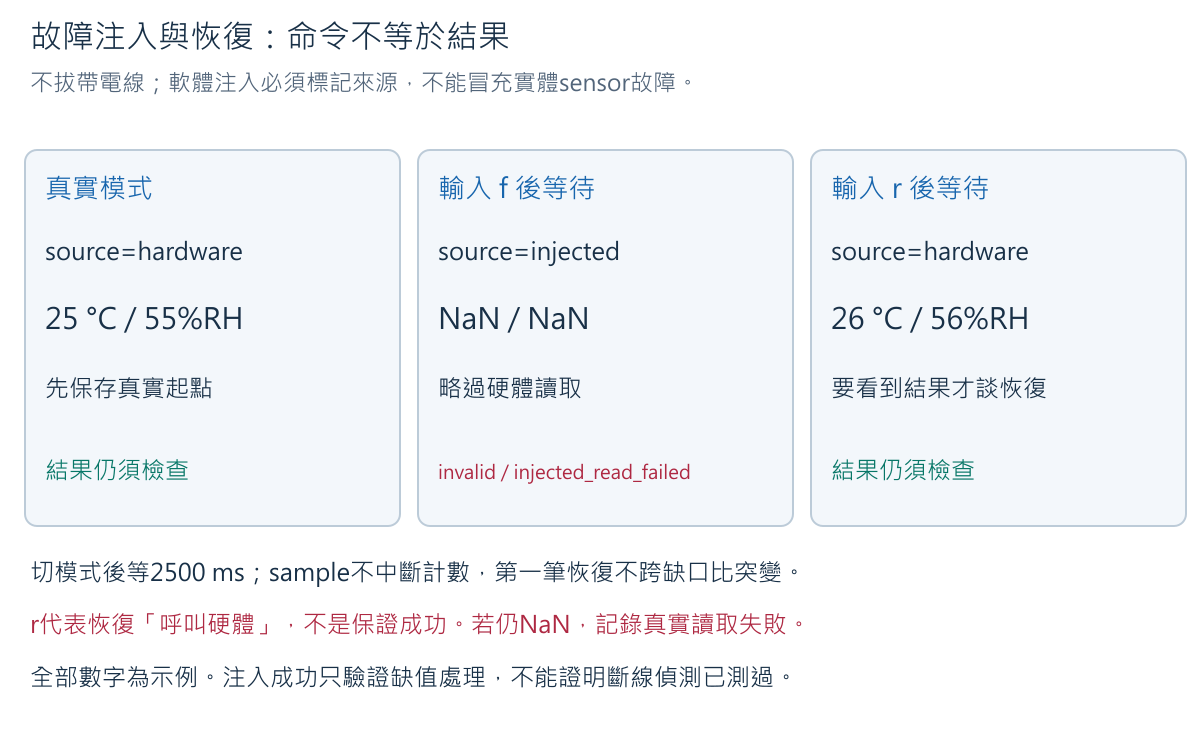

### 12.2 一個人也能做的完整流程

1. 已核准接線、正常上電、Monitor 115200，保留至少3筆真實模式資料作起點。
   若原本已read_failed，先按14節排查，不把它當成功起點。
2. 不碰接線，在Monitor輸入`f` Enter。應看到`event=mode source=injected next_read_after_ms=2500`。
   等至少3列sample：兩值nan、`valid=false quality=invalid reason=injected_read_failed`。
3. 逐列保存原始文字。f模式不呼叫sensor，縱使實體仍正常，也會顯示注入缺值。
   這些列不得算成實體故障樣本或溫濕度實測。
4. 輸入`r` Enter。應看到`event=mode source=hardware next_read_after_ms=2500`。
   等下一輪實際讀取；如果成功，保留至少3列真實資料，說明各列quality。
5. 若仍read_failed，只能寫「已取消注入，真實讀取未恢復」。先保存log、關Monitor、
   拔USB，再查接線、profile、版本與供電，修正後另開一次上電記錄，不抹掉失敗。

**示例輸出（非實測）：**

```text
event=mode source=injected next_read_after_ms=2500
device=DEMO sensor=dht11 source=injected sample=11 uptime_ms=30000 temperature_c=nan humidity_pct=nan valid=false quality=invalid reason=injected_read_failed
event=mode source=hardware next_read_after_ms=2500
device=DEMO sensor=dht11 source=hardware sample=12 uptime_ms=35000 temperature_c=26.0 humidity_pct=56.0 valid=true quality=usable reason=basic_checks_passed
```

切模式會清掉前值比較；第一筆恢復值不與失敗前一筆跨缺口算突變。
`sample`繼續遞增而不是回1，因為沒有重啟；RST才會重新開始本次開機的計數。
恢復三筆只支持「在這次條件下能再次讀取」，不能保證未來不再失敗。

### 12.3 若真的讀不到，library做了什麼？

1.4.7的DHT讀取會檢查回覆脈衝等候與資料校驗；讀取失敗時read函式可回傳NaN。
程式以`isfinite`處理缺值，不從NaN直接判斷是斷線、電源、時序或sensor損壞。
本週`f`直接注入NaN測應用層，沒有真的測到library的超時或校驗失敗路徑。
真實原因若未取得證據，紀錄寫「原因待查」，不捏造確診。

**練習Q2：** 按r後第一筆仍是`source=hardware ... valid=false reason=read_failed`，
同學說「r已執行，所以恢復成功」。對嗎？

**答案：** r只代表恢復呼叫硬體讀取，不代表回覆成功。這一列明確失敗。
要區分命令接受、實際讀取及通過檢查三件事；先保存失敗列再斷電核對。
即使之後讀到25 °C，也只支持後續那一輪成功，不能回頭改寫這次缺值。


<a id="w4-integration"></a>

## 12A、整合兩種感測器與蜂鳴器：一次可信事件，一次短提示

### 12A.1 整合的目的不是把數字排在同一行

KY-018適合觀察遮光變化，DHT11提供溫度與相對濕度。它們量不同的事，更新速度也不同。
同時整合的成果是：光線有變化時仍持續追蹤溫濕度，失敗時能說出是哪一個來源出了問題；
蜂鳴器將新遮光事件轉成可察覺的提示。這是Week 7遊戲的輸入事件練習，還不是完整遊戲。

圖中實線表示外部功能連接，方框不代表實物腳序。感測資料各走自己的路徑，
共同GND是準位與供電回路的參考，不是把S、DATA與控制腳短接在一起。

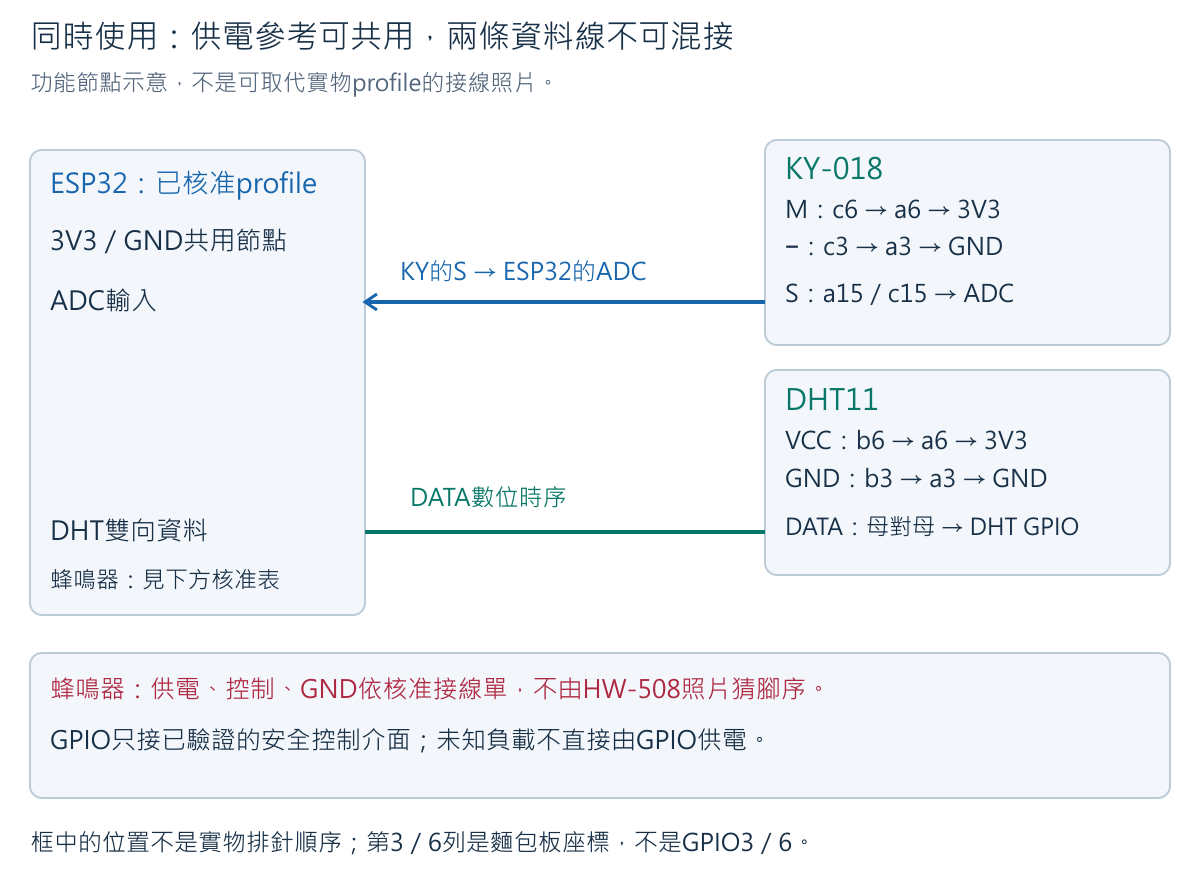

### 12A.2 先辨認蜂鳴器，不能只看購物品名

下圖是教師實拍，PCB可辨識為HW-508；購買頁名為KY-012。
照片偏模糊，不能用圖片補猜腳位，也未證明它與任何品牌KY-012電路完全相同。

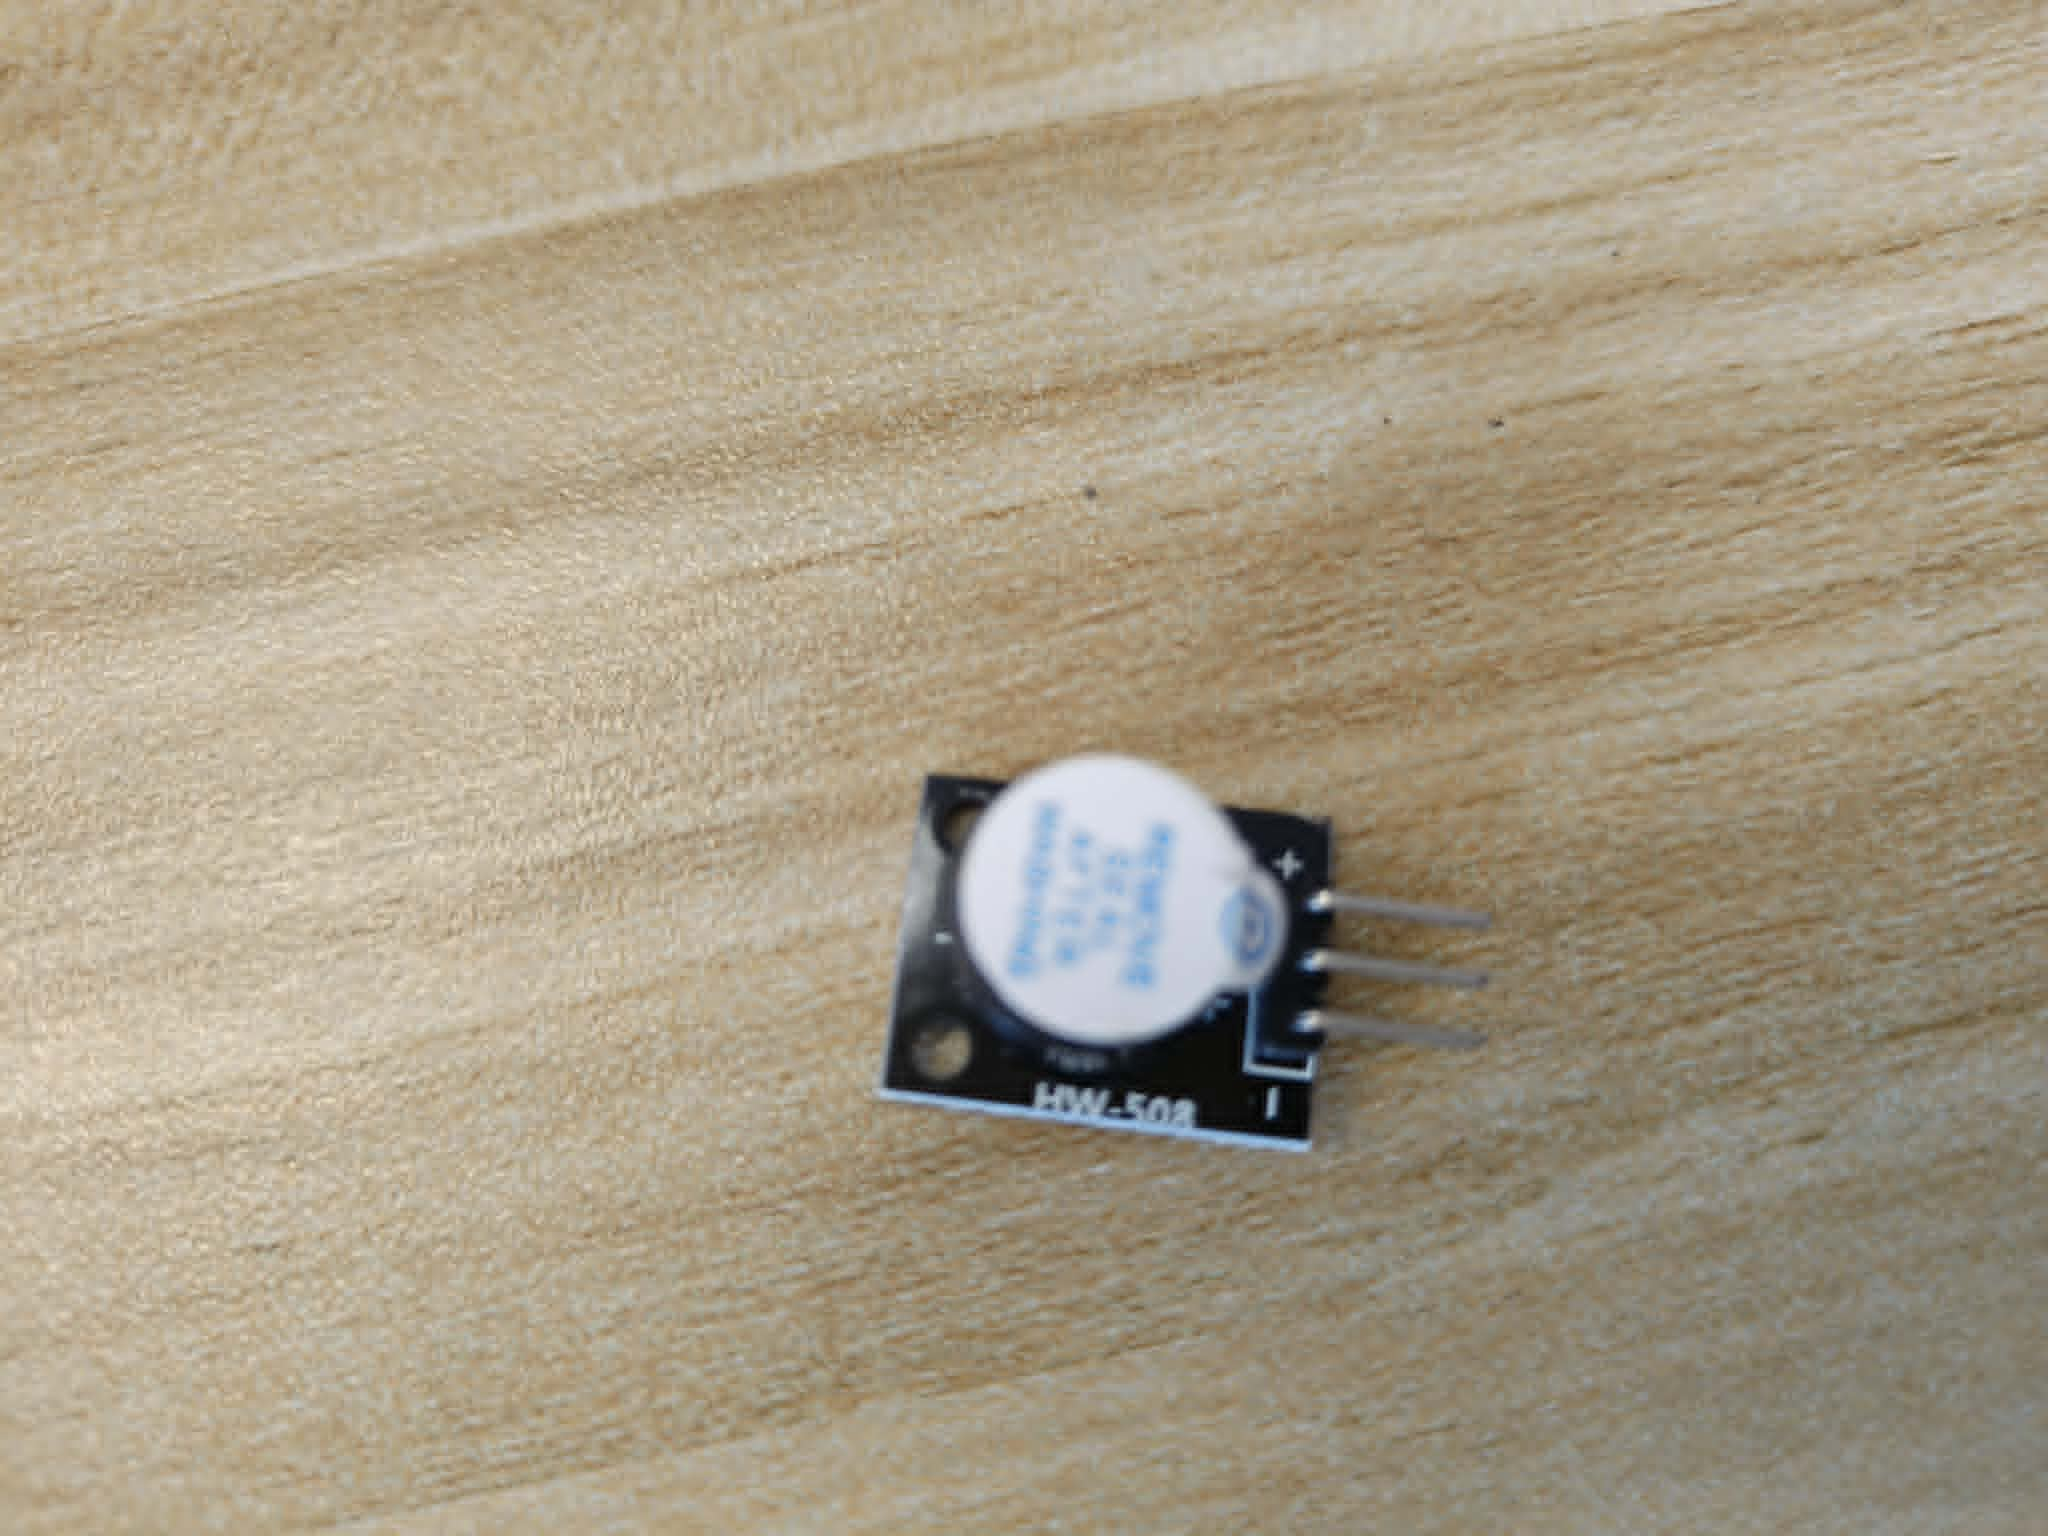

蜂鳴器（buzzer）把電能轉為聲音。有源型（active buzzer）內部有振盪電路，
在符合規格的驅動條件下發聲；無源型（passive buzzer）通常需要外部交替訊號。
正式程式可選直接開／關或2000 Hz波形；選項代表驅動方式，不用發聲結果猜測內部種類。
[Joy-IT KY-012說明](https://sensorkit.joy-it.net/en/sensors/ky-012)是該品牌模組參考，
不是教師這片HW-508的驗證文件。

接電前的核准表不可留空：

| 核准項目 | 需要的證據 | 未確認的處理 |
|---|---|---|
| 實物PCB與功能腳 | 正背清晰照片、可追溯電路與量測 | 不由S、+、−或腳數猜實際角色 |
| 供電與工作電流 | 指定電壓、啟動／工作電流、板上電源能力 | 不先試5Vin或未知5 V |
| 控制端 | 3.3 V邏輯相容、輸入電流、是否內建驅動 | 未證明安全不能當GPIO可直驅負載 |
| 驅動方式 | 直接開／關需核對HIGH或LOW；HW-508波形需核對指定接法及串聯1 kΩ | 不明時保留旗標false，不嘗試提高電壓 |
| 上電／Reset | 程式尚未setup時也不持續發聲，輸出預設安全 | 不能只靠setup之後寫LOW作保證 |
| 固定接法與GPIO | 確切起終點、供電／控制／回路、各腳用途 | `PIN_BUZZER_CONTROL=-1`與旗標false |

若實物是直接兩端供電發聲、未有相容控制級，且GPIO電流能力不足，
需先決定合適的驅動方案；這屬待教師核准的硬體決定，不在本課自行增加採購或叫學生硬接。
本程式不把「通過編譯」當作已核准。本次無外部電池，供電只能採已驗證的本地方案。

### 12A.2A 電表的1、三支腳與「沒聲音」要分開判斷

電阻檔的2 kΩ是量程（range），不是「給零件2千伏」，也不是越大就越強。
電表用內部測試訊號估算電阻；不同檔位的測試條件依電表而異，因此只在元件與外部電源分離後量測。
對本課A830L，單獨顯示`1`表示本檔未取得範圍內的阻值，**不是1 Ω**。
量已知220 Ω時可能是檔位太小；量不明電子模組時，也可能是開路、接觸或內部電路的影響，
不能把兩種情境都判成「換大檔就一定好」。

三支金屬腳不一定有三種電氣功能。空接腳（NC，not connected）仍可有金屬排針，
但沒有接入預期電路。HW-508參考資料有中間NC的版本；本次實物的外側−／+與中間腳
仍依確切資料核對，不能照其他三線模組把它接成VCC、GND、S。
紙上「REMOVE SEAL AFTER WASHING」是製造清洗後移除封貼的提示，不是叫使用者洗蜂鳴器，
也不能用有沒有貼紙來判斷有源或無源。

2026-09-07的BOARD-T01紀錄中，外側兩腳及中間腳對兩側的2 kΩ量測都回報`1`；
限流直流測試沒有聲音，之後保留串聯1 kΩ，以2000 Hz、200 ms的受限波形測試，使用者回報有聲音。
這是**指定接法的發聲觀察**，不是工作電流量測，也沒有證明內部構造或所有同名模組均可直驅。
已聽到聲音後不必為了填表重做相同量測。

| 看見或聽見什麼 | 可以記錄什麼 | 還不能推論什麼 |
|---|---|---|
| 電阻檔單獨顯示1 | 本次未取得範圍內阻值 | 必然損壞、必然NC、阻值為1 Ω |
| 直流限流測試安靜 | 該條件未聽到聲音 | 必然無源、一定需要更高電壓 |
| `beep=command` | 程式接受了短聲要求 | 實物已發聲 |
| `beep=off ... sound_observation=pending` | 程式結束此次輸出，待人工聽辨 | 已用麥克風量到聲音與長度 |
| 使用者回報有聲音 | 此顆、此接線與波形有可聽反應 | 可拔掉限流電阻或改用6.6 V |

**判讀練習：** 已顯示DONE，再送b得到`not_ready_or_used_or_button_held`，是蜂鳴器壞了嗎？

**預期答案：** 不是故障證據。該診斷程式每次開機只允許一次短聲；DONE表示這次額度已使用，
同一條拒絕訊息也涵蓋尚未準備好或按鈕未放開。先看狀態，不反覆送b或改線。
有必要再測時，先確認接法與1 kΩ未變、電池及舵機未連入、按鈕放開，再重啟等待READY；
沒有自動重播，仍須明確送b。已取得所需觀察就停止，不增加音量試極限。

完整接法、三支診斷程式與實際紀錄見[BOARD-T01實測交接](../docs/lab_notes/2026-09-07-week7-bringup.md)。
正式程式已加入相同頻率的波形選項，但仍須選定模式並核對接法，**不能只代入GPIO就視為已完成整合**。
現行[Espressif LEDC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/ledc.html)
的`ledcWriteTone`以腳位為參數；舊版以通道為參數的範例不能混貼。課堂正式程式的核准閘門維持不變。

### 12A.2B 正式程式要選哪個設定？

先回答「這顆用哪種訊號才會響？」，再填設定，不以購物品名作答案。

| 已核准的接法 | 程式設定 | 關閉方式 |
|---|---|---|
| 可用有效準位控制的有源模組或驅動電路 | `BUZZER_USE_TONE=false`；`BUZZER_ON_LEVEL`填核准的HIGH或LOW | 輸出相反準位 |
| BOARD-T01留存的HW-508受限波形接法 | `BUZZER_USE_TONE=true`；核對實物串聯1 kΩ後才填`BUZZER_SERIES_OHMS=1000` | PWM工作週期歸零，保持LOW |

第二列只適用已核對的那顆與接法：核准GPIO經1 kΩ到外側+，外側−回共同GND，中間腳不接。
不要再把3V3接到同一GPIO節點，也不要省略電阻。程式中的1000只是人填入的紀錄，不能偵測電阻有沒有裝。
此模式不使用`BUZZER_ON_LEVEL`，可保留−1；其他GPIO、感測器與蜂鳴器確認旗標仍須個別核准。

例如新遮光事件發生於1000 ms，Week 4以1120 ms關閉為目標；Week 7失敗音則以200 ms為目標。
音調期間仍回到`loop()`處理停止，不用`delay(200)`卡住。2000 Hz是波形頻率，120／200 ms才是輸出時長。
既有診斷只回報200 ms有聲音，不能據此宣稱Week 4的120 ms整合提示已聽測。

若LEDC初始化失敗，程式停在blocked；發聲或停止API失敗後不再發聲，斷電檢查後重新啟動。
Week 4的`u`不能清掉這種故障；`beep_off`只表示結束輸出命令，不表示已量測真實聲長。

### 12A.3 兩個感測器的同時接線表

先保存DHT單獨程式與log，關Monitor、拔USB、PWR熄、電表OFF。
板子放在麵包板旁，不把寬板硬壓進去。
以下感測器接法只適用已確認3.3 V供電及相容訊號的兩片模組。
第9節原DHT供電在c6／c3，**現在移到b6／b3，空出的c6／c3給KY**；
同列電氣等效，但不能讓兩個公頭擠同一個洞。這就是換階段需要重新追線的地方。

| 起點 | 經過的孔位或接頭 | 終點與用途 |
|---|---|---|
| ESP32已辨認3V3 | 公對母，公頭a6 | 第6列a～e供電節點 |
| ESP32已辨認GND | 公對母，公頭a3 | 第3列a～e共同GND |
| DHT VCC | 公對母，公頭b6 | 同列接到3V3 |
| DHT GND | 公對母，公頭b3 | 同列接到共同GND |
| DHT DATA | 一條母對母直接到核准`PIN_DHT` | 不接KY的S或第15列 |
| KY中間供電腳M | 公對母，公頭c6 | 同列接到3V3；M為本課代稱 |
| KY − | 公對母，公頭c3 | 同列接到共同GND |
| KY S | 公對母，公頭a15 | 類比訊號節點 |
| 核准`PIN_LIGHT` | 公對母，公頭c15 | 讀S相對共同GND的電壓 |
| 電表測點（需要時） | 公對公e3、e6、e15 | 延長GND、3V3、S，不把三個自由端相碰 |
| 蜂鳴器的核准控制端 | 依核准表接`PIN_BUZZER_CONTROL` | 只接已驗證的控制介面；不套用照片左右順序 |
| 蜂鳴器供電與回路 | 依核准表的電源來源、端點及共地路徑 | 此處沒有通用三腳供電答案；無核准表不得接電 |

三個GPIO必須不同，程式也會阻擋重複數字。麵包板第3列不是GPIO3，
第15列不是GPIO15，程式裡只填已核准的實際GPIO。
第3與第6列經各自模組形成負載路徑，不能用普通導線直接相連。
不靠「通斷沒響」單獨判定整套系統安全，仍需比對供電、模組與接線核准表。

### 12A.4 完整整合程式與更新節奏

先理解三個時間：KY每50 ms檢查、DHT每2500 ms嘗試一輪、Serial每500 ms摘要。
三者不必一起等2500 ms。新事件開啟蜂鳴器後，以經過120 ms作關閉目標，
不寫一段`delay(120)`等待；程式仍可檢查輸入與處理靜音。
DHT函式本身仍有有限的同步讀取時間，整支程式不能被宣稱為所有函式都無阻塞。

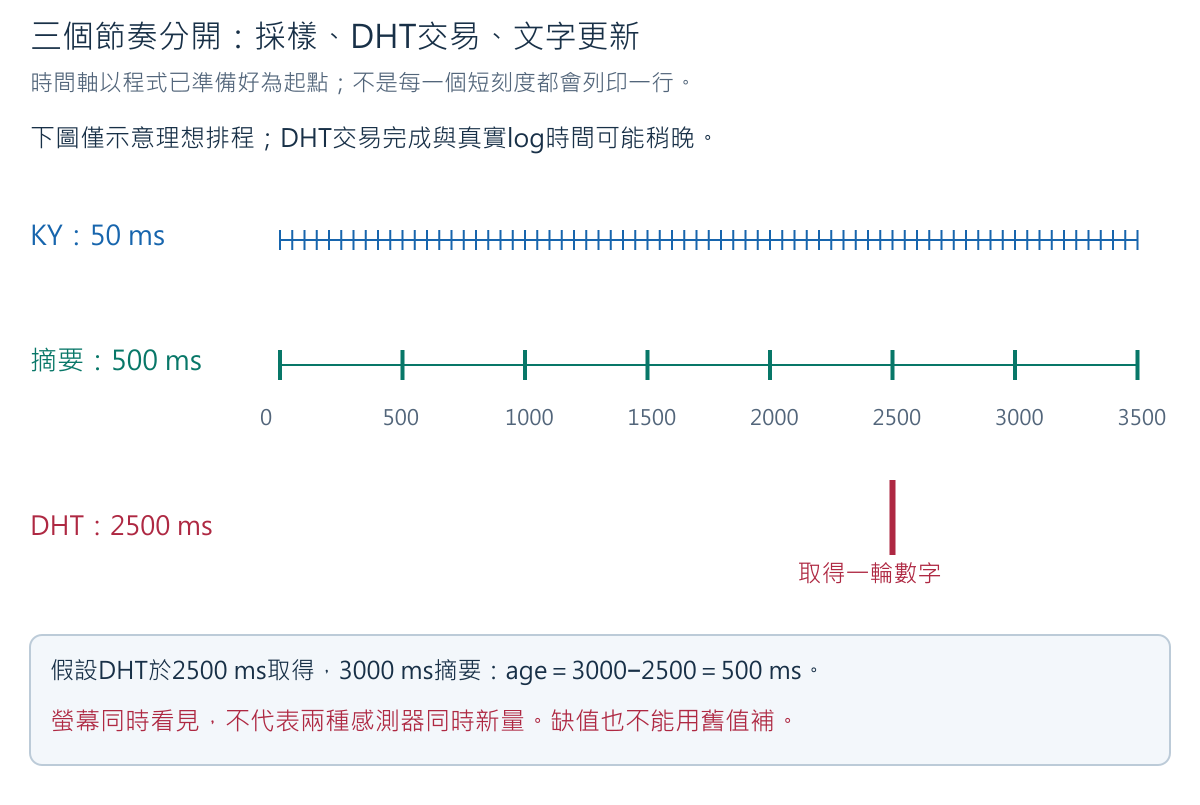

圖中的DHT採樣間隔較寬，不是漏掉KY的同時資料；每種感測器有自己的筆序與時間。
「資料年齡」（age）是現在減去該筆取得時間。例如DHT在2500 ms取得，
3000 ms摘要時age＝500 ms；溫度欄若沿用該筆，就不能聲稱3000 ms又量了一次。

開啟[`week04_dual_sensor_alarm.ino`](../examples/week04_dual_sensor_alarm/week04_dual_sensor_alarm.ino)。
本冊完整C++內容如下，不需要另外拼接兩支loop。


In [ ]:
#include <Arduino.h>
#include <DHT.h>
#include <math.h>

// Published defaults are deliberately blocked. No inferred module pin order.
const int PIN_LIGHT = -1;
const int PIN_DHT = -1;
const int PIN_BUZZER_CONTROL = -1;
const bool SENSOR_PROFILES_CONFIRMED = false;
const bool BUZZER_PROFILE_CONFIRMED = false;
const int BUZZER_ON_LEVEL = -1; // Set HIGH or LOW only from the approved driver profile.
const bool BUZZER_USE_TONE = false;
const int BUZZER_SERIES_OHMS = -1; // HW-508 tone path requires a verified 1 kOhm resistor.
const uint32_t BUZZER_HZ = 2000;
const int INDOOR_MIN = -1;
const int INDOOR_MAX = -1;
const int SHADE_MIN = -1;
const int SHADE_MAX = -1;
const char *DEVICE_ID = "CHANGE_ME";
const uint32_t LIGHT_INTERVAL_MS = 50;
const uint32_t DHT_INTERVAL_MS = 2500;
const uint32_t STABLE_MS = 150;
const uint32_t BEEP_MS = 120;
const uint32_t PRINT_INTERVAL_MS = 500;

DHT dht(PIN_DHT, DHT11);
bool ready = false, shadeHigher = true;
int threshold = -1;
bool injectDht = false, injectLight = false;
bool muted = false, beepActive = false;
bool buzzerFault = false;
uint32_t beepStarted = 0, lastLight = 0, lastDht = 0, lastPrint = 0;
uint32_t lightSample = 0, dhtSample = 0, coverEvents = 0;
int lightRaw = -1;
bool lightValid = false;
// -1: no accepted stable classification yet; 0: indoor; 1: covered.
int candidate = -1, stable = -1;
uint32_t candidateSince = 0;
bool armed = false;
float temperatureC = NAN, humidityPct = NAN;
bool haveDht = false, dhtValid = false, previousDhtValid = false;
float previousC = 0, previousRh = 0;
uint32_t previousDhtMs = 0, dhtAt = 0;
const char *dhtQuality = "invalid", *dhtReason = "not_sampled";

bool configureCalibration() {
  if (INDOOR_MIN <= 0 || SHADE_MIN <= 0 || INDOOR_MAX >= 4095 || SHADE_MAX >= 4095 ||
      INDOOR_MIN > INDOOR_MAX || SHADE_MIN > SHADE_MAX) return false;
  if (INDOOR_MAX < SHADE_MIN) {
    shadeHigher = true; threshold = (INDOOR_MAX + SHADE_MIN) / 2;
  } else if (SHADE_MAX < INDOOR_MIN) {
    shadeHigher = false; threshold = (SHADE_MAX + INDOOR_MIN) / 2;
  } else return false;
  return true;
}

bool profileReady() {
  return SENSOR_PROFILES_CONFIRMED && BUZZER_PROFILE_CONFIRMED &&
         PIN_LIGHT >= 0 && PIN_DHT >= 0 && PIN_BUZZER_CONTROL >= 0 &&
         PIN_LIGHT != PIN_DHT && PIN_LIGHT != PIN_BUZZER_CONTROL && PIN_DHT != PIN_BUZZER_CONTROL &&
         (BUZZER_USE_TONE ? BUZZER_SERIES_OHMS == 1000 :
          (BUZZER_ON_LEVEL == HIGH || BUZZER_ON_LEVEL == LOW));
}

void silence() {
  if (BUZZER_USE_TONE) {
    if (!ledcWrite(PIN_BUZZER_CONTROL, 0)) {
      ledcDetach(PIN_BUZZER_CONTROL);
      digitalWrite(PIN_BUZZER_CONTROL, LOW); pinMode(PIN_BUZZER_CONTROL, OUTPUT);
      if (!buzzerFault) Serial.println("event_type=buzzer_fault reason=tone_stop_failed restart_required=true");
      buzzerFault = true; muted = true;
    }
  } else digitalWrite(PIN_BUZZER_CONTROL, BUZZER_ON_LEVEL == HIGH ? LOW : HIGH);
  beepActive = false;
}

bool initializeBuzzer() {
  digitalWrite(PIN_BUZZER_CONTROL, BUZZER_USE_TONE ? LOW : 1-BUZZER_ON_LEVEL);
  pinMode(PIN_BUZZER_CONTROL, OUTPUT);
  if (BUZZER_USE_TONE && !ledcAttach(PIN_BUZZER_CONTROL, BUZZER_HZ, 10)) return false;
  silence();
  return !buzzerFault;
}

void startBeep(uint32_t now) {
  if (buzzerFault) return;
  if (BUZZER_USE_TONE) {
    if (ledcWriteTone(PIN_BUZZER_CONTROL, BUZZER_HZ) == 0) {
      buzzerFault = true; muted = true; silence();
      Serial.println("event_type=buzzer_fault reason=tone_start_failed restart_required=true");
      return;
    }
  } else digitalWrite(PIN_BUZZER_CONTROL, BUZZER_ON_LEVEL);
  beepActive = true; beepStarted = now;
}

void serviceBeep(uint32_t now) {
  if (beepActive && now - beepStarted >= BEEP_MS) {
    silence();
    Serial.printf("device_id=%s event_type=beep_off uptime_ms=%lu reason=duration_elapsed\n", DEVICE_ID, (unsigned long)now);
  }
}

void resetLightState() {
  candidate = stable = -1;
  armed = false; // A new stable release is required after any invalid interval.
}

void readLight(uint32_t now) {
  ++lightSample;
  lightRaw = injectLight ? -1 : analogRead(PIN_LIGHT);
  // Controller policy is stricter than Week 3's candidate label: outside observed span is rejected.
  lightValid = !injectLight && lightRaw > 0 && lightRaw < 4095 &&
               lightRaw >= min(INDOOR_MIN, SHADE_MIN) && lightRaw <= max(INDOOR_MAX, SHADE_MAX);
  if (!lightValid) { resetLightState(); silence(); return; }
  const bool lowSide = lightRaw <= threshold;
  const int current = (shadeHigher ? !lowSide : lowSide) ? 1 : 0;
  if (candidate != current) { candidate = current; candidateSince = now; }
  if (now - candidateSince < STABLE_MS || stable == candidate) return;
  stable = candidate;
  Serial.printf("device_id=%s event_type=light_stable state=%s uptime_ms=%lu source=hardware\n",
                DEVICE_ID, stable ? "SHADE" : "INDOOR", (unsigned long)now);
  if (stable == 0) { armed = true; return; }
  if (!armed) return; // Booting while covered is not a new cover action.
  armed = false;
  ++coverEvents;
  Serial.printf("device_id=%s event_type=cover_event count=%lu uptime_ms=%lu buzzer_command=%s\n",
                DEVICE_ID, (unsigned long)coverEvents, (unsigned long)now, muted ? "muted" : "on");
  if (!muted) {
    startBeep(now);
  }
}

void readDht(uint32_t now) {
  (void)now; // Acquisition timestamp is taken after the synchronous library call.
  ++dhtSample;
  temperatureC = humidityPct = NAN;
  if (!injectDht) { humidityPct = dht.readHumidity(); temperatureC = dht.readTemperature(); }
  dhtAt = millis(); // Acquisition completion time; not the KY sample's timestamp.
  haveDht = true; dhtValid = true;
  dhtQuality = "usable"; dhtReason = "basic_checks_passed";
  if (!isfinite(temperatureC) || !isfinite(humidityPct)) {
    dhtValid = false; dhtQuality = "invalid";
    dhtReason = injectDht ? "injected_read_failed" : "read_failed";
  } else if (humidityPct < 0 || humidityPct > 100) {
    dhtValid = false; dhtQuality = "invalid"; dhtReason = "rh_out_of_bounds";
  } else if (temperatureC < 10 || temperatureC > 40) {
    dhtQuality = "suspect"; dhtReason = "outside_classroom_policy";
  } else if (previousDhtValid && dhtAt - previousDhtMs <= 2 * DHT_INTERVAL_MS &&
             (fabsf(temperatureC - previousC) > 5 || fabsf(humidityPct - previousRh) > 10)) {
    dhtQuality = "suspect"; dhtReason = "abrupt_change";
  }
  previousDhtValid = dhtValid && !injectDht;
  if (previousDhtValid) { previousC=temperatureC; previousRh=humidityPct; previousDhtMs=dhtAt; }
  // Report each sensor's own acquisition, rather than faking simultaneous samples.
  Serial.printf("device_id=%s sensor=dht11 source=%s sample=%lu uptime_ms=%lu temperature_c=%.1f humidity_pct=%.1f valid=%s quality=%s reason=%s\n",
                DEVICE_ID, injectDht ? "injected" : "hardware", (unsigned long)dhtSample,
                (unsigned long)dhtAt, temperatureC, humidityPct, dhtValid ? "true" : "false", dhtQuality, dhtReason);
}

void setup() {
  Serial.begin(115200); delay(500);
  if (!profileReady() || !configureCalibration()) {
    Serial.println("week=4 status=blocked reason=profile_or_calibration_missing"); return;
  }
  // The approved module must also remain quiet before setup and during reset.
  if (!initializeBuzzer()) {
    Serial.println("week=4 status=blocked reason=buzzer_init_failed"); return;
  }
  analogReadResolution(12); analogSetPinAttenuation(PIN_LIGHT, ADC_11db);
  dht.begin();
  lastLight = lastDht = lastPrint = millis(); ready = true;
  Serial.printf("week=4 status=ready device_id=%s threshold=%d light_interval_ms=%lu dht_interval_ms=%lu stable_ms=%lu beep_ms=%lu\n",
                DEVICE_ID, threshold, (unsigned long)LIGHT_INTERVAL_MS, (unsigned long)DHT_INTERVAL_MS,
                (unsigned long)STABLE_MS, (unsigned long)BEEP_MS);
  Serial.println("commands=f:inject_dht k:inject_light r:resume_both q:mute u:unmute");
}

void loop() {
  if (!ready) return;
  uint32_t now = millis();
  serviceBeep(now);
  if (Serial.available()) {
    const char c=Serial.read();
    if (c=='f' || c=='r') { injectDht=c=='f'; previousDhtValid=false; haveDht=false; dhtValid=false; temperatureC=humidityPct=NAN; lastDht=now; }
    if (c=='k' || c=='r') { injectLight=c=='k'; lightRaw=-1; lightValid=false; resetLightState(); silence(); }
    if (c=='q') { muted=true; silence(); }
    if (c=='u' && !buzzerFault) muted=false; // Does not replay a previous event.
    if (c!='\n' && c!='\r' && c!=' ') {
      const bool known=c=='f'||c=='k'||c=='r'||c=='q'||(c=='u'&&!buzzerFault);
      Serial.printf("device_id=%s event_type=command status=%s command=%c uptime_ms=%lu\n", DEVICE_ID, known?"accepted":"rejected", c, (unsigned long)now);
    }
  }
  if (now-lastLight >= LIGHT_INTERVAL_MS) { lastLight=now; readLight(now); }
  // Avoid a DHT transaction while a beep is active, so it cannot lengthen this pulse.
  if (!beepActive && now-lastDht >= DHT_INTERVAL_MS) { lastDht=now; readDht(now); }
  now=millis(); serviceBeep(now);
  if (now-lastPrint >= PRINT_INTERVAL_MS) {
    lastPrint=now;
    Serial.printf("device_id=%s sensor=ky018 source=%s sample=%lu uptime_ms=%lu age_ms=%lu light_raw=%d valid=%s state=%s candidate=%d armed=%s event_count=%lu\n",
                  DEVICE_ID, injectLight?"injected":"hardware", (unsigned long)lightSample, (unsigned long)lastLight, (unsigned long)(now-lastLight),
                  lightRaw, lightValid?"true":"false", stable<0?"UNKNOWN":stable?"SHADE":"INDOOR", candidate,
                  armed?"true":"false", (unsigned long)coverEvents);
    if (!haveDht) Serial.println("sensor=dht11 snapshot=none valid=false age_ms=unknown");
    else Serial.printf("sensor=dht11 snapshot=latest source=%s age_ms=%lu valid=%s quality=%s reason=%s\n",
                       injectDht?"injected":"hardware", (unsigned long)(now-dhtAt),
                       dhtValid?"true":"false", dhtQuality, dhtReason);
  }
}


### 12A.5 主要變數與判斷為何這樣安排

- `PIN_LIGHT`、`PIN_DHT`、`PIN_BUZZER_CONTROL`分別指向三條不同訊號功能；
  profile旗標確認的是硬體條件，不是學生為了讓程式跑就任意改true。
- 四個`*_MIN/MAX`取自Week 3原始紀錄；`configureCalibration()`再檢查分離與方向。
  本週用於聲音事件的`lightValid`更保守：超出兩組合起來的觀察範圍就拒絕，
  但中間空隙允許候選經過。這是控制政策，不是「raw在區間內就一定真實可靠」。
- `candidate`與`candidateSince`記錄最新分類及它持續多久。`stable`是已接受的狀態，
  `armed`只在穩定解除後變true；一次遮光事件後變false，避免遮著不放一直響。
- `resetLightState()`在缺值時清除穩定狀態和armed，恢復後須先解除再遮光。
  不能把失敗前的室內狀態留著，然後把恢復時已有的遮光誤認成新動作。
- `readDht()`延續單獨程式的有限值、RH範圍、教室溫度及突變檢查；
  每個來源自己的valid分開，不用`KY正常 && DHT正常`掩蓋哪一個失敗。
- `haveDht=false`表示目前沒有可展示的本輪DHT紀錄；不是0 °C。
  失敗的一輪保留NaN與原因，不把前次成功數字填回去。
- `serviceBeep()`在每輪及DHT返回後檢查是否到關閉目標。蜂鳴期間暫緩開始DHT交易，
  避免新交易拖長這次短鳴；DHT可能因此稍晚取樣，時間須看真實log。
  Serial傳輸、loop延遲與硬體仍會影響實際時間，120 ms不是已實測的最長停止保證。
- `q`只靜音並停止目前蜂鳴，不切斷電源；沒有鎖定故障時，`u`解除靜音，不補播之前事件。
  發熱、異味、持續不受控聲音或重啟時直接拔USB，不等待命令回應。

### 12A.6 上傳後依序驗證，不同功能一次只改一件

1. 全部profile未核准前只Verify。核准後填GPIO、兩個旗標及自己的四個校正值；
   依12A.2B選發聲方式：開／關模式填HIGH或LOW，波形模式核對串聯1 kΩ並填阻值確認。
   使用第10節相同DHT library及ESP32編譯設定，保存自己的整合版本。
2. 模組暫不接電，先只用ESP32完成Verify及Upload；這個階段的未接感測結果不作實驗資料。
   再拔USB，依第12A.3表與蜂鳴器核准表接入模組。需要電表測點就在斷電時固定。
3. 上電前逐條追供電與訊號，確認無裸端互碰；接USB後先確認安靜、無異常。
   開115200 baud Monitor，核對`week=4 status=ready`及本輪參數。
4. 不遮光等待穩定解除，應見`light_stable state=INDOOR`與摘要`armed=true`。
   DHT約在起始等待2500 ms後有自己的第一筆，不要求立刻出溫濕度。
5. 固定遮光約一秒，應見一個`cover_event`及一聲短提示。保持遮光再等一秒，
   事件數不再增加，不持續發聲。移開並保持至少300 ms，再遮光一次，才應新增一個事件。
6. 保持線路不動，在Monitor的輸入／傳送區送`q`，下一次合格遮光仍有事件但`buzzer_command=muted`。
   送`u`只恢復未來事件的聲音，不應立刻補响。這是在區分輸入事件與輸出政策。
7. 保存一段同時包含兩個來源的原始log，核對KY採樣、DHT筆序、age、事件及beep_off。
   不必再做十次相同遮光；需要的是「新遮光、保持、解除後再遮、靜音」不同規則的證據。

正常格式示例（數字只是示例，並非實測）：

```text
device_id=DEMO event_type=light_stable state=INDOOR uptime_ms=650 source=hardware
device_id=DEMO event_type=cover_event count=1 uptime_ms=1150 buzzer_command=on
device_id=DEMO event_type=beep_off uptime_ms=1270 reason=duration_elapsed
device_id=DEMO sensor=dht11 source=hardware sample=1 uptime_ms=3025 temperature_c=25.0 humidity_pct=50.0 valid=true quality=usable reason=basic_checks_passed
sensor=dht11 snapshot=latest source=hardware age_ms=475 valid=true quality=usable reason=basic_checks_passed
```

`count`是新遮光事件數，不是DHT筆數；`buzzer_command=on`只證明軟體下命令，
實際短聲及停止仍需觀察。`snapshot=latest`表示摘要引用最近一次DHT結果，不是又新量一次。
若`valid=false`，這筆最近結果就是失敗紀錄；即使age很小也不能當正常溫度。
本程式的示例欄位`device_id`是裝置代碼，與前面單獨程式的`device`是同一概念，
不能把兩個來源的`sample=1`誤當同一個取樣事件。

### 12A.7 安全故障與恢復：故障來源分開，不拔帶電線

| 操作 | 保持什麼不變 | 預期結果與判讀 |
|---|---|---|
| 送`f`，等下一輪DHT | 接線與光線不變 | DHT為source=injected、NaN及invalid；KY仍可記錄事件 |
| 送`k`，等下一次KY | 接線不變 | KY為source=injected、raw=−1、UNKNOWN、armed=false；蜂鳴停止 |
| 送`r` | 不Reset、不改線 | 兩者回真實讀取；DHT重新等2500 ms，成功與否看結果 |
| 恢復時先保持遮光 | 光線不變 | 不立刻響；先穩定解除，再穩定遮光才可觸發 |

`f`只注入DHT，`k`只注入KY，兩者可同時啟用，`r`取消兩者。
−1與NaN在這裡是軟體注入，不是拔掉S一定會量到的值。
串列命令已accepted只表示程式接受，真正恢復需後續source=hardware、有效數字及行為證據。
不要把注入錯誤算入真正感測器故障率。
有足夠既有單獨DHT的f/r紀錄時，只需補本次「DHT失敗時KY持續」及
「KY失敗／恢復不虛增事件」兩項新整合證據。

### 12A.8 練習與回饋

**題A：** DHT失敗但KY正常，能不能把整行資料寫成`valid=true`，因為大部分數字還在？

**解答：** 不能。每個來源分別保存有效性與理由；KY可用不會把NaN變成溫度。
共同畫面可以同時顯示光線狀態與「溫濕度讀取失敗」，沒有必要讓所有資料一同消失。
反過來，DHT正常也不證明KY事件可信。

**題B：** 遮住5秒，程式採到100筆遮光，為什麼只響一次？

**解答：** 100是採樣筆數，1是合格的解除→遮光轉換次數。
事件發生後armed=false，直到重新穩定解除才變true。以第6節時間圖指出重新準備點。
常見錯誤是把`if (raw > threshold)`每次都當新事件；若實測一直響，
先看穩定狀態是否因邊界波動反覆解除，不直接下結論說蜂鳴器壞了。

**題C：** 同一刻看到KY摘要與DHT最近值，可以說它們同時量到嗎？

**解答：** 不行。看各自sample、uptime_ms、age_ms。DHT資料可能比KY舊，
兩個函式也不是在完全同一個瞬間交易。若要作時間比較，先寫可接受的資料年齡與同步需求，
不能只把文字排成一行就宣稱同步。本週也不推論「遮光導致溫度改變」，因為沒有因果實驗。

**題D：** `beep_off`印出而實物仍響，該怎麼寫結論？

**解答：** 軟體已到關閉分支，實體關閉未通過。先拔USB，再核對有源／無源、
啟動準位、接線、驅動與供電；不把文字作已停止的唯一證據。
未量測最長反應時間時，不能宣稱「任何故障120 ms內停止」。


<a id="w4-discussion"></a>

## 十三、Week 4 Discussion：有數字，就代表感測資料可信嗎？

「可信」要先指定用途。例如只分這張桌上的室內光／遮光，與要量照度lux，
所需證據不同。本節沿同一條問題線往下：數字含義→波動→基準→新資料→失敗→恢復→結論。
所有表中數字均為**教學示例**，不是學生或教師的實測；自己的答案應另引用自己的log。

### 13.1 第一題：先讀懂數字，再談信任

**已知／問題：** 同學A記錄「KY raw=900」，B記錄「DHT temperature_c=25.0」，
C記錄「330 Ω電阻在20k檔顯示0.33」。三個數字各代表什麼？900是否就是900 lux？

**需要概念：** ADC原始碼、單位、電表量程、標稱／量測。

**預期答案與推理：** A為ADC無單位原始碼，需本地條件與校正才能分類，沒有照度校正不能叫900 lux。
B是解碼的攝氏溫度，還缺來源與quality等檢查，不是25 V。
C若已確認此電表20k檔用kΩ顯示，0.33 kΩ×1000=330 Ω；不是0.33 Ω。
先辨認量與單位，才有資格比較大小。

**常見錯誤／限制：** 三個數字不能放一起平均；顯示剛好330不證明零誤差。
參考第4節量程圖與第10節類比／數位圖。缺電表型號、檔位或單位時，C也只能待確認。

### 13.2 第二題：有波動就壞了嗎？

**已知／問題：** KY在固定室內光取10筆，依5.1資料300～320，平均310；
另一組同樣平均310，但包含200與420。哪組比較適合用單一門檻？還缺什麼？

**需要概念：** 平均、min／max／span、控制變因。

**預期答案與步驟：** 第一組已知span=20；第二組至少span=420−200=220。
相同平均藏住不同波動。第一組在此次條件較穩，但還要看遮光組與獨立驗證才能判斷門檻是否可用。
不能只說第一組「準確」；穩定是重複性，準確還需相應參考。

**常見錯誤／限制：** 不刪掉200／420讓結果好看，不從兩個極值補造第二組其餘8筆。
先看是否移動、手影、照明或接觸改變；接線需調整時先斷電。用第12A節的採樣時間圖說明每筆的條件及各來源時間應分開。

### 13.3 第三題：如何讓比較真的在比較光線？

**已知／問題：** 室內組用原桌面，遮光組把sensor拿到衣服裡並換取樣間隔。
看到遮光raw較大，能否把全部差異歸因於遮光？請改寫成可重現程序。

**需要概念：** 自變因、控制變因、標記條件與原始證據。

**預期答案：** 不能。位置、方向、接線拉動、等待、取樣間隔同時改變。
固定同一模組、位置方向、照明、供電、程式與500 ms間隔；只加／移固定遮光物，
每條件等待相同操作時間，各記10筆及條件。遮光物不要碰裸接點；手忙時先安放好再輸入命令。
控制變因是讓比較可解釋，不是宣稱環境絕對不變。

**常見錯誤／限制：** 不要求三種光線、不把搬位置視為單純遮光。
即使新程序做得好，仍是本地相對比較，不得到通用lux標準或所有模組的方向。

### 13.4 第四題：何時能算門檻，何時應停止？

**已知／問題：** A：室內300～320，遮光900～920。
B：室內300～700，遮光600～1000。兩組都能用平均中點保證分開嗎？
用A建門檻後，新室內raw=950又代表什麼？

**需要概念：** 不重疊區間、門檻、訓練／驗證分開、class與quality。

**預期答案與步驟：** A最近的兩端為320與900，threshold=(320+900)÷2=610。
室內在低側，所以raw≤610分INDOOR，>610分SHADE。B的600～700重疊，程式阻擋校正；
單靠raw無法保證分開同值來自哪種條件。新950在A規則下是SHADE但quality=suspect，
因超過基準觀察上限920；又與已知室內標記不符，需保留為不符案例。

**常見錯誤／限制：** 不用建基準的原資料就宣稱「已驗證」，不把950改標遮光。
Week 3第十二之一節兩張區間圖說明可分與不可分，本週不重做基準實驗。若重建基準，需另留新驗證；十筆不能證明未來永遠不重疊。

### 13.5 第五題：valid=true就一定能用嗎？

**已知／問題：** 獨立案例，前值皆25 °C、50%RH，2.5秒後有：
A NaN／50，B 25／140，C 45／50，D 31／50，E 25／50。
請分valid、quality、reason，並說明哪一筆證明sensor準確。

**需要概念：** 第11節分層檢查、警示政策與精度限制。

**預期答案：** A invalid/read_failed（若真實來源）；B invalid/rh_out_of_bounds；
C valid但suspect/outside_classroom_policy；D valid但suspect/abrupt_change；
E valid、usable/basic_checks_passed。**沒有任何一筆單獨證明準確**。
先查有限值，再RH，再政策，最後突變；第11節流程圖亦是程式if／else if順序。

**常見錯誤／限制：** 不把45 °C直接宣判損壞，不把NaN當0，不把0～100%RH視為感測器完整規格。
警示可能來自環境、位置或資料問題；未查證不能確診。

### 13.6 第六題：失敗可不可以用上次成功值補齊？

**已知／問題：** 三列為真實25 °C、軟體注入NaN、取消注入後真實26 °C。
同學算平均時改成25、25、26，說「比較完整」。哪裡不對？r後仍NaN又怎麼記？

**需要概念：** 缺值、來源、分母、恢復證據。

**預期答案與推理：** 第二個25是捏造該輪實測。保留原始3列；若明確只描述兩筆真實有效值，
其平均=(25+26)÷2=25.5 °C，分母為2，另外報告注入缺值1筆。
但這段包含人工注入且觀察稀少，不能拿來推定正常環境平均或實體故障率。
r後仍NaN，記source=hardware/read_failed，表示已取消注入但尚未恢復成功。

**常見錯誤／限制：** 不刪失敗列、不填0、不把所有三列平均、不把注入算真實sensor故障。
第12節時間圖把命令與結果分開；恢復成功只支持這次後續能讀，不是永久修復保證。

### 13.7 第七題：寫一段有證據、也有界限的結論

**已知／問題：** 用自己的兩種光線log、DHT真實／注入／恢復紀錄與電阻量程結果，
回答主題「有數字，就代表感測資料可信嗎？」若DHT實物profile尚未核准，又怎麼寫？

**需要概念：** 本週所有概念串成來源→操作→檢查→用途→限制，不增加新活動。

**合理答案框架（空格由自己實測填，不是要求填成功）：**

> 我想判斷＿＿。資料來自＿＿板卡／模組、＿＿版本、＿＿條件。
> KY兩組各＿＿筆，區間為＿＿與＿＿，門檻＿＿／未建立原因＿＿。
> 新驗證＿＿筆，其中符合＿＿、不符＿＿、無法判斷＿＿；可疑＿＿筆另註。
> DHT真實讀取＿＿筆、基本有效＿＿筆、可疑＿＿筆；注入＿＿筆分開保存。
> 取消注入後觀察＿＿，因此只能支持＿＿；仍不能宣稱＿＿。
> 電阻測值＿＿的單位由＿＿量程／顯示確認；未核對項目為＿＿。
> 整合時兩種來源的更新間隔與age為＿＿；保持遮光時事件數＿＿、聲音＿＿。
> 注入DHT與KY失敗後，另一種來源及armed的行為分別為＿＿；因此目前可支持＿＿用途。

**推理與預期重點：** 數字只是起點，需要來源、單位、控制條件、失敗處理及適用目的。
如果DHT未核准，寫「實物接線／Upload／讀值未進行；只完成文件、示例判讀或編譯」，
不可拿Notebook示例當自己的log。KY重疊也應如實報告「目前規則不足」。

**常見錯誤／限制：** 不寫沒有數據的「全部正常」「精度高」「所有環境通用」。
不要把本課政策寫成原廠規格，也不要把一次成功讀值當整批板卡驗證。
證據不夠時能清楚說明缺什麼，就是有根據的分析，而不是把空格填滿。


<a id="w4-records"></a>

## 十四、遇到不同結果：先安全，再查最小範圍

| 症狀 | 第一個安全動作 | 接著查什麼／不能推定什麼 |
|---|---|---|
| Ω讀值一直跳、接近50多才偶爾很小 | 外部電源分離，放穩電阻與測點 | 接觸、檔位、表筆孔；不一手按小零件一手追表筆 |
| 220／330在200檔顯示1或OL | 停讀並確認是Ω功能、電阻仍隔離 | 是否超量程；不是1 Ω，不用通斷蜂鳴代替數值 |
| KY開始blocked/profile_missing | 不接未核准GPIO | 核准表、自己程式；不能拿GPIO數字填上就說實機通過 |
| 整合blocked/profile_or_calibration_missing | 不接未核准負載 | 三個GPIO、相容性、啟動準位、四個範圍及重疊；缺少哪項就補哪項證據 |
| KY基準重疊、端點或新值超範圍 | 先保存原始值；若改線先拔USB | 條件與接線；端點不必然斷線，超範圍不必然sensor壞 |
| Serial亂碼／空白 | 不動感測線 | baud115200、Port、開場、profile、正確sketch；RST會清除事件與暫存狀態，設定常數仍保留 |
| DHT.h找不到或重複library提示 | 停在Verify，無須上電 | Adafruit作者與版本、安裝路徑；保留完整錯誤 |
| DHT只有read_failed | 保存log、拔USB | 核准腳位、供電、DATA／GND、GPIO、DHT11類型、版本及間隔 |
| DHT每筆相同 | 保持線路不動、看序號時間來源 | 穩定環境與更新特性；不直接判卡住，不用熱水／吹氣 |
| f後沒有hardware資料 | 不拔線 | source=injected是刻意注入；用r取消，等下一輪，不重啟來掩蓋 |
| r後仍invalid | 保存後斷電 | 取消注入與真實成功不同；不能宣稱恢復 |
| 發熱、異味、重啟、供電異常 | 立即拔USB | 停止接電，核對profile與電路；不改用5Vin試運氣 |

## 十五、個人紀錄與完成條件

### 15.1 紀錄的最小欄位

| 紀錄 | 自己要保存什麼 | 可檢查的完成條件 |
|---|---|---|
| 電阻 | 型式／色環／標稱／容差、表型號、檔位、完整顯示與單位、220／330各列量程比較 | 可換算Ω／kΩ，辨別超量程、測值與標稱；沒有其他並聯線路 |
| KY基準銜接 | 引用Week 3四個範圍值、原始log、GPIO與程式版本，註明條件是否改變 | 可追溯，不重收同目的資料；變更時才補受影響基準 |
| 整合與新事件 | 候選／穩定／armed、保持遮光、解除後再遮、靜音與beep_off，DHT及KY各自筆序和時間 | 保持遮光不重複；聲音與軟體命令分開；失敗／恢復不虛增事件 |
| DHT實物 | 第8節核准表、正背與接線照片、母對母DATA路徑、供電檢查 | 功能起終點清楚，無猜腳序；未核准保留待驗 |
| DHT程式 | IDE／board package／libraries版本、Verify與Upload分開、真實10筆 | 每欄位能解釋，序號與時間完整；失敗也留列 |
| 失敗與恢復 | 真實→注入→取消後真實，含source與命令；已有單獨紀錄可引用，補兩個新整合案例 | DHT失敗不掩蓋KY；KY失敗清除armed，恢復需先解除；取消不等於成功 |
| Discussion | 先寫自己的預測，再對照參考答案，註明修正理由與證據 | 一段有用途、有依據、有界限的結論 |

起點／恢復三筆可以從上述真實10筆中明確引用，不必為相同目的重做全部實驗。
若缺安全profile或硬體，圈出未執行項目並保存已完成的閱讀／計算／Verify成果；
此時是部分完成，不能將該硬體能力勾成已實作。
量測可共用電表，個人證據與判讀仍分開保存，不填同學的數字作自己的量測。

### 15.2 延伸只沿本週主題，不是另買器材

完成共同核心後，可用**複製的示例資料**比較不同取樣筆數對區間與門檻的影響，
或把Q1的教室警示界限改得較窄，先預測哪些列改判，再在離線資料表逐列比較。
延伸答案應指出：更多樣本可能暴露更大波動，不保證平均必然更準；
警示較多也不等於sensor較差，可能只是政策較嚴。保留原始版本，不把延伸政策悄悄替換共同程式。
沒有新硬體、新網路或新評量要求。

## 十六、斷電、收納與本週總結

1. 複製完整log到自己的紀錄，檔名含週次、板卡代碼、條件／來源；不要只存最後一行。
2. IDE儲存自己的sketch；關Monitor、拔USB，確認PWR熄。電表轉OFF。
3. 先取下表筆與測點延長線，再取DATA及供電線；不拉細線硬扯母頭、不讓排針彎折。
4. 220／330依標稱放回原電阻包，感測器與線分開收好。記下本次未核准／未解決問題。
5. 下週加入RGB／OLED前依當週教材重新確認，不把本週接線當成SG90供電方案。蜂鳴器依核准方式斷電後拆除。

本週完成的不是「所有數字都對」，而是能說明**量的是什麼、怎麼取得、哪些檢查做過、
還不能支持什麼結論**。這些條件將成為後續單機互動使用感測資料的基礎。

### 技術來源與適用範圍

- [Vishay電阻色碼](https://www.vishay.com/docs/49411/resistor_color_code_calculator.pdf)：色環規則，不是本包電阻實測值。
- [Fluke電阻量測](https://www.fluke.com/en-ie/learn/blog/digital-multimeters/how-to-measure-resistance)：隔離外部電源等原則，不代替A830L確切版本手冊。
- [Espressif ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)：ADC設定與raw意義，不是KY-018照度校正。
- [VCC-GND YD-ESP32-S3](https://github.com/vcc-gnd/YD-ESP32-S3)：板卡來源文件入口，須核對Type-A V1.5與實物差異，不由系列名稱推出已實測GPIO。
- [DHT library 1.4.7原始程式](https://github.com/adafruit/DHT-sensor-library/blob/1.4.7/DHT.cpp)：讀取、快取與失敗回傳，不代替YS-31載板電氣確認。
- [香港天文台相對濕度](https://www.weather.gov.hk/en/education/meteorological-instruments/automatic-weather-stations/00714-Lets-talk-about-relative-humidity.html)：物理量定義，不是這一片DHT11精度證明。

所有示意圖為教學模型；實拍保留實物原貌。編譯、host測試與實機證據互不替代，
上電條件及待驗項目以第2、8節與硬體紀錄為準。
